# EDA

Identifying high level patterns, substructures, missing elements, and flaws in the datasets 

## Loading datasets

In [1]:
# Convert raw csv files into pandas dataframes

import pandas as pd

ALE_RAW = "../data/raw/account_lifecycle_events.csv"
UEM_RAW = "../data/raw/user_engagement_metrics.csv"
SIH_RAW = "../data/raw/support_interaction_history.csv"

ale_df = pd.read_csv(ALE_RAW, parse_dates=['created_timestamp', 'last_activity_timestamp', 'status_change_date', 'contract_end_date'])
uem_df = pd.read_csv(UEM_RAW, parse_dates=['user_created_date', 'last_login_date'])
sih_df = pd.read_csv(SIH_RAW, parse_dates=['created_date', 'resolved_date'])

# pandas treats the string 'NA' as null by default — restore North America region
ale_df['region'] = ale_df['region'].fillna('NA')


In [2]:
# Generate sweetviz profiles on the three datasets for quick references 

# import sweetviz as sv
# import os

# ale_report = sv.analyze(ale_df)
# uem_report = sv.analyze(uem_df)
# sih_report = sv.analyze(sih_df)

# ale_report.show_html("../data/profiles/ale_report.html", open_browser=False)
# uem_report.show_html("../data/profiles/uem_report.html", open_browser=False)
# sih_report.show_html("../data/profiles/sih_report.html", open_browser=False)

## Preprocessing

### Converting timestamps to durations

Confirm all date columns parse to the same dtype across the three datasets before computing durations.

Timestamp columns are converted to integer day offsets relative to a `SNAPSHOT_DATE` anchored to the latest record across the three CSV files. This is the next best alternative to an actual extraction date.

**Sign convention:** `(snapshot_date - col).dt.days`  
- Positive → event is in the past (e.g. account created 400 days ago)  
- Negative → event is in the future (e.g. `days_since_contract_end = -30` means contract ends in 30 days)

In [3]:
# Verify dtype and sample values for every timestamp column across all three datasets

timestamp_cols = {
    'ALE': ['created_timestamp', 'last_activity_timestamp', 'status_change_date', 'contract_end_date'],
    'UEM': ['user_created_date', 'last_login_date'],
    'SIH': ['created_date', 'resolved_date'],
}
frames = {'ALE': ale_df, 'UEM': uem_df, 'SIH': sih_df}

for table, cols in timestamp_cols.items():
    df = frames[table]
    for col in cols:
        sample = df[col].dropna().iloc[0] if df[col].notna().any() else None
        print(f"{table}.{col:35s}  dtype={str(df[col].dtype):20s}  sample={sample}")
    print()

ALE.created_timestamp                    dtype=datetime64[us]        sample=2022-08-17 00:00:00
ALE.last_activity_timestamp              dtype=datetime64[us]        sample=2024-12-21 00:00:00
ALE.status_change_date                   dtype=datetime64[us]        sample=2023-12-17 00:00:00
ALE.contract_end_date                    dtype=datetime64[us]        sample=2024-08-16 00:00:00

UEM.user_created_date                    dtype=datetime64[us]        sample=2022-09-01 00:00:00
UEM.last_login_date                      dtype=datetime64[us]        sample=2024-12-18 00:00:00

SIH.created_date                         dtype=datetime64[us]        sample=2023-02-12 00:00:00
SIH.resolved_date                        dtype=datetime64[us]        sample=2023-02-13 02:03:45.742785



In [4]:
# Create metadata df for timeframe columns based on operational use case

timestamp_metadata = pd.DataFrame([
    {'field': 'created_timestamp',       'csv_file': 'ale', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'last_activity_timestamp', 'csv_file': 'ale', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'status_change_date',      'csv_file': 'ale', 'forward_looking': True,  'use_for_snapshot': False},  # can record future scheduled changes, leakage risk
    {'field': 'contract_end_date',       'csv_file': 'ale', 'forward_looking': True,  'use_for_snapshot': False},  # no leakage risk, expect negative durations at times
    {'field': 'user_created_date',       'csv_file': 'uem', 'forward_looking': False, 'use_for_snapshot': False},  # creation dates lag activity cutoff so best not to include in snapshot
    {'field': 'last_login_date',         'csv_file': 'uem', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'created_date',            'csv_file': 'sih', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'resolved_date',           'csv_file': 'sih', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
]).set_index('field')
display(timestamp_metadata)

,csv_file,forward_looking,use_for_snapshot
field,,,
created_timestamp,ale,False,True
last_activity_timestamp,ale,False,True
status_change_date,ale,True,False
contract_end_date,ale,True,False
user_created_date,uem,False,False
last_login_date,uem,False,True
created_date,sih,False,True
resolved_date,sih,False,True


In [5]:
# Calculating snapshot date based on 

snapshot_cols = timestamp_metadata[timestamp_metadata['use_for_snapshot']]

SNAPSHOT_DATE = pd.concat([
    ale_df[snapshot_cols[snapshot_cols['csv_file'] == 'ale'].index],
    uem_df[snapshot_cols[snapshot_cols['csv_file'] == 'uem'].index],
    sih_df[snapshot_cols[snapshot_cols['csv_file'] == 'sih'].index]
]).max().max().normalize()

print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

Snapshot date: 2025-01-02


In [6]:
# Observing the min and max range for timestamps to confirm usage in snapshot calculations

max_rows = []
for field, row in timestamp_metadata.iterrows():
    df = frames[row['csv_file'].upper()]
    max_rows.append({
        'field': field,
        'csv_file': row['csv_file'],
        'forward_looking': row['forward_looking'],
        'use_for_snapshot': row['use_for_snapshot'],
        'min_value': df[field].min(),
        'max_value': df[field].max()
    })

max_df = pd.DataFrame(max_rows).set_index('field')
display(max_df)

,csv_file,forward_looking,use_for_snapshot,min_value,max_value
field,,,,,
created_timestamp,ale,False,True,2022-01-01 00:00:00.000000,2024-12-31 00:00:00.000000
last_activity_timestamp,ale,False,True,2024-09-18 00:00:00.000000,2024-12-31 00:00:00.000000
status_change_date,ale,True,False,2022-02-21 00:00:00.000000,2026-04-21 00:00:00.000000
contract_end_date,ale,True,False,2023-01-01 00:00:00.000000,2026-12-31 00:00:00.000000
user_created_date,uem,False,False,2022-01-02 00:00:00.000000,2025-03-30 00:00:00.000000
last_login_date,uem,False,True,2024-07-04 00:00:00.000000,2024-12-31 00:00:00.000000
created_date,sih,False,True,2022-01-04 00:00:00.000000,2025-01-01 00:00:00.000000
resolved_date,sih,False,True,2022-01-05 13:43:15.337997,2025-01-02 20:28:49.046460


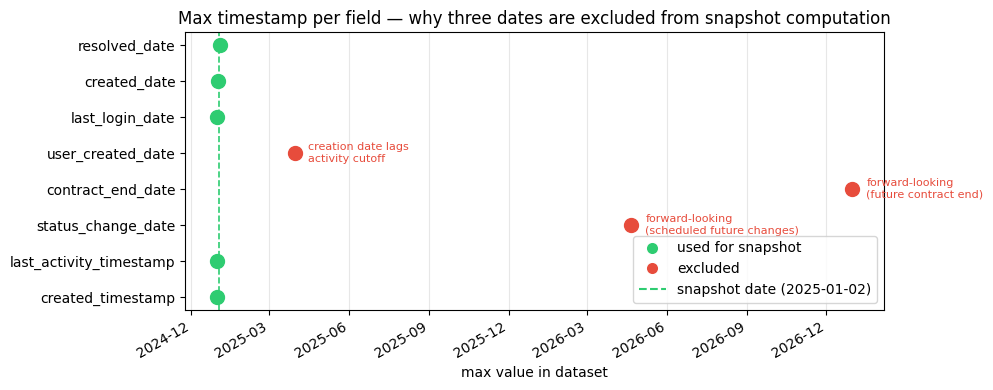

In [7]:
# Plotting max timestamp to visually confirm outliers

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CLUSTER_DATE = pd.Timestamp("2025-01-02")
exclusion_reasons = {
    'status_change_date': 'forward-looking\n(scheduled future changes)',
    'contract_end_date':  'forward-looking\n(future contract end)',
    'user_created_date':  'creation date lags\nactivity cutoff',
}

fig, ax = plt.subplots(figsize=(10, 4))

for i, (field, row) in enumerate(max_df.iterrows()):
    color = '#2ecc71' if row['use_for_snapshot'] else '#e74c3c'
    ax.scatter(row['max_value'], i, color=color, s=100, zorder=3)
    if field in exclusion_reasons:
        ax.annotate(
            exclusion_reasons[field],
            xy=(row['max_value'], i),
            xytext=(10, 0), textcoords='offset points',
            va='center', fontsize=8, color='#e74c3c',
        )

ax.axvline(CLUSTER_DATE, color='#2ecc71', linestyle='--', linewidth=1.2, label=f'snapshot date ({CLUSTER_DATE.date()})')

ax.set_yticks(range(len(max_df)))
ax.set_yticklabels(max_df.index)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
ax.set_xlabel('max value in dataset')
ax.set_title('Max timestamp per field — why three dates are excluded from snapshot computation')

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=9, label='used for snapshot'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=9, label='excluded'),
    Line2D([0], [0], color='#2ecc71', linestyle='--', label=f'snapshot date ({CLUSTER_DATE.date()})'),
]
ax.legend(handles=legend_handles, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

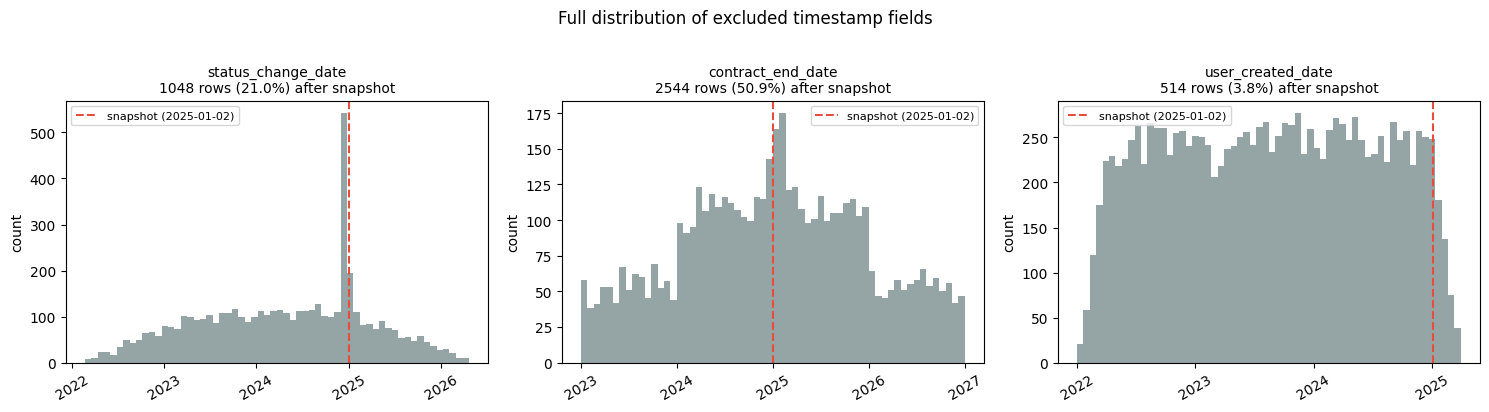

In [8]:
# Plotting distribution of excluded fields to show future events

excluded_meta = timestamp_metadata[timestamp_metadata['use_for_snapshot'] == False]

excluded_fields = {
    field: frames[row['csv_file'].upper()][field]
    for field, row in excluded_meta.iterrows()
}

fig, axes = plt.subplots(1, len(excluded_fields), figsize=(15, 4), sharey=False)

for ax, (field, series) in zip(axes, excluded_fields.items()):
    non_null = series.dropna()
    ax.hist(non_null, bins=60, color='#95a5a6', edgecolor='none')
    ax.axvline(SNAPSHOT_DATE, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'snapshot ({SNAPSHOT_DATE.date()})')
    future_count = (non_null > SNAPSHOT_DATE).sum()
    future_pct = future_count / len(non_null) * 100
    ax.set_title(f'{field}\n{future_count} rows ({future_pct:.1f}%) after snapshot', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.set_ylabel('count')

plt.suptitle('Full distribution of excluded timestamp fields', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Function to convert timestamps in data to durations (in days), mutating the df in-place

def timestamps_to_durations(df, column_map, reference_date):
    """
    Add signed integer day-offset columns to df in-place and drop the source timestamp columns.

    column_map: {src_col: dst_col}  e.g. {'created_timestamp': 'days_since_creation'}
    reference_date: pd.Timestamp — the "as-of" date; use SNAPSHOT_DATE, not today.
    """
    for src_col, dst_col in column_map.items():
        df[dst_col] = (reference_date - df[src_col]).dt.days

In [10]:
ale_column_map = {
    'created_timestamp':       'days_since_creation',
    'last_activity_timestamp': 'days_since_last_activity',
    'contract_end_date':       'days_since_contract_end',   # negative = contract hasn't ended yet
    'status_change_date':      'days_since_status_change',  # spike near snapshot — see next cell
}

uem_column_map = {
    'last_login_date':   'days_since_last_login',
    'user_created_date': 'days_since_user_creation',
}

sih_column_map = {
    'created_date':  'days_since_ticket_creation',
    'resolved_date': 'days_since_resolution',
}

timestamps_to_durations(ale_df, ale_column_map, SNAPSHOT_DATE)
timestamps_to_durations(uem_df, uem_column_map, SNAPSHOT_DATE)
timestamps_to_durations(sih_df, sih_column_map, SNAPSHOT_DATE)

display(ale_df[list(ale_column_map.values())].head(3))
display(uem_df[list(uem_column_map.values())].head(3))
display(sih_df[list(sih_column_map.values())].head(3))

,days_since_creation,days_since_last_activity,days_since_contract_end,days_since_status_change
0,869,12,139,382
1,1046,11,316,731
2,534,23,169,157


,days_since_last_login,days_since_user_creation
0,15,854
1,6,856
2,11,797


,days_since_ticket_creation,days_since_resolution
0,690,688
1,342,340
2,394,392


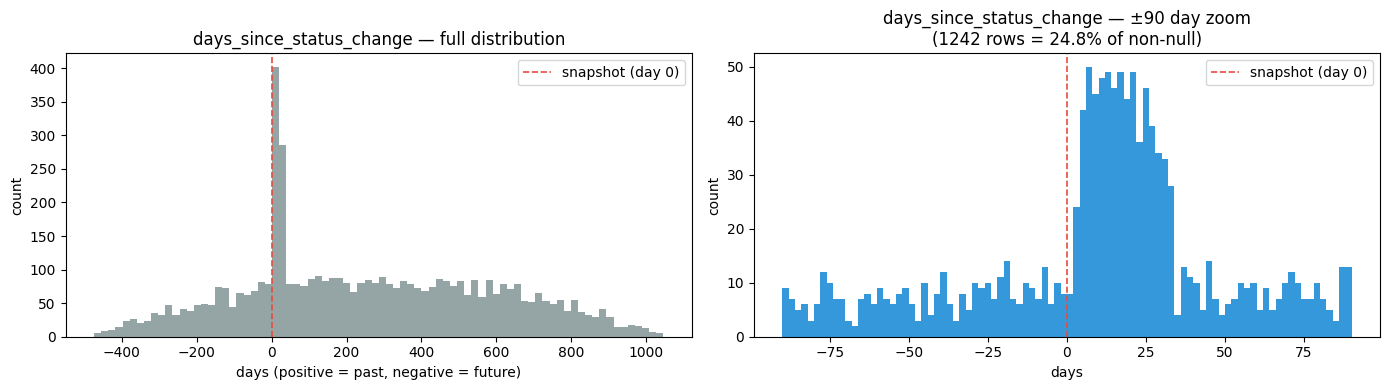

count    5000.000000
mean      253.638800
std       332.683659
min      -474.000000
25%        11.000000
50%       213.000000
75%       515.250000
max      1046.000000

Rows at exactly day 0 (status_change = snapshot date): 3
Rows within ±7 days of snapshot:                       155
Rows within ±30 days of snapshot:                      766


In [11]:
# Investigate days_since_status_change — cell-11 flagged an anomalistic spike near the snapshot date

col = 'days_since_status_change'
series = ale_df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(series, bins=80, color='#95a5a6', edgecolor='none')
axes[0].axvline(0, color='#e74c3c', linestyle='--', linewidth=1.2, label='snapshot (day 0)')
axes[0].set_title(f'{col} — full distribution')
axes[0].set_xlabel('days (positive = past, negative = future)')
axes[0].set_ylabel('count')
axes[0].legend()

window = series[(series >= -90) & (series <= 90)]
axes[1].hist(window, bins=90, color='#3498db', edgecolor='none')
axes[1].axvline(0, color='#e74c3c', linestyle='--', linewidth=1.2, label='snapshot (day 0)')
axes[1].set_title(f'{col} — ±90 day zoom\n({len(window)} rows = {len(window)/len(series)*100:.1f}% of non-null)')
axes[1].set_xlabel('days')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(series.describe().to_string())
print(f"\nRows at exactly day 0 (status_change = snapshot date): {(series == 0).sum()}")
print(f"Rows within ±7 days of snapshot:                       {((series >= -7) & (series <= 7)).sum()}")
print(f"Rows within ±30 days of snapshot:                      {((series >= -30) & (series <= 30)).sum()}")

In [ ]:
# Check if the spike in account changes correlates with target

### Dropping obvious non-features

Candidate list:

**ALE**
- `account_uuid` --> signal already encoded by region and days_since_creation

**UEM**
- `account_uuid` --> redundant (ale)
- `user_email` --> redundant (1-1 with user_id)

**SIH**
- `account_uuid` --> redundant (ale)
- `org_id` --> redundant (ale)
- `retention_offer_accepted` (>99% false, <1% true) --> (no variance)
- `csat_score` --> deprecated, duplicate of satisfaction_score

In [12]:
# Test whether ale.account_uuid rows are redundant and encoded in other columns

has_uuid = ale_df["account_uuid"].notna()

is_eu        = ale_df["region"] == "EU"
is_post_2023 = ale_df["created_timestamp"] >= pd.Timestamp("2023-01-01")

both_conditions = is_eu & is_post_2023

total_with_uuid     = has_uuid.sum()
match_both          = (has_uuid & both_conditions).sum()
eu_only             = (has_uuid & is_eu & ~is_post_2023).sum()
post_2023_only      = (has_uuid & ~is_eu & is_post_2023).sum()
neither             = (has_uuid & ~is_eu & ~is_post_2023).sum()

print(f"Rows with non-null account_uuid:              {total_with_uuid}")
print(f"  match EU + created >= 2023:                 {match_both}  ({match_both/total_with_uuid*100:.1f}%)")
print(f"  EU only (created before 2023):              {eu_only}  ({eu_only/total_with_uuid*100:.1f}%)")
print(f"  created >= 2023 only (non-EU):              {post_2023_only}  ({post_2023_only/total_with_uuid*100:.1f}%)")
print(f"  neither condition (unexpected):             {neither}  ({neither/total_with_uuid*100:.1f}%)")

Rows with non-null account_uuid:              1071
  match EU + created >= 2023:                 1071  (100.0%)
  EU only (created before 2023):              0  (0.0%)
  created >= 2023 only (non-EU):              0  (0.0%)
  neither condition (unexpected):             0  (0.0%)


In [ ]:
# Check if retention_offer_accepted has variance < 1%

In [ ]:
# Check if csat_score is duplicated

In [13]:
# Obvious drops — identified by data dictionary and high-level smell tests

ALE_OBVIOUS_DROPS = ['account_uuid', 'data_residency_region']
UEM_OBVIOUS_DROPS = ['account_uuid', 'user_email']
SIH_OBVIOUS_DROPS = ['account_uuid', 'org_id', 'retention_offer_accepted', 'csat_score']


### Investigating the grace period backfill gap

The data dictionary says that `grace_period` was introduced in v2.1 but not all historical data was backfilled. This means some accounts may show `active` when they should show `grace_period`.

Why this matters for the model:  

If accounts in the grace period are misidentified as active, there would be active accounts that semantically closer to the positive class than the negative. This would reduce model recall because we would be supressing important signals that a customer is about to churn

In [14]:
# Count suspect actives by applying a proxy signature to the active cohort
# Proxy: annual contract has ended (days_since_contract_end > 0), any contract has ended, and auto_renew_enabled == False
# Strategy: create lists of suspects based on annual contracts ending and auto-renewal status

active_df = ale_df[ale_df['account_status'] == 'active'].copy()

contract_lapsed = active_df['days_since_contract_end'] > 0
annual_contract_lapsed = contract_lapsed & (active_df['billing_cycle'] == 'annual')
no_auto_renew = active_df['auto_renew_enabled'] == False

# Hard: annual contract lapsed + no auto-renew (strongest signal — annual expiry is unambiguous)
suspect_hard = active_df[annual_contract_lapsed & no_auto_renew]

# Medium: any billing cycle lapsed + no auto-renew
suspect_medium = active_df[contract_lapsed & no_auto_renew]

# Easy: any lapsed contract regardless of auto-renew setting (loosest — includes renewal lag noise)
suspect_easy = active_df[contract_lapsed]

print(f"Active accounts total: {len(active_df)}")
print(f"\nSuspect active (hard: annual lapsed + no auto-renew):")
print(f"Count: {len(suspect_hard)}  ({len(suspect_hard)/len(active_df)*100:.1f}% of actives)")
print(f"\nSuspect active (medium: any lapsed + no auto-renew):")
print(f"Count: {len(suspect_medium)}  ({len(suspect_medium)/len(active_df)*100:.1f}% of actives)")
print(f"\nSuspect active (easy: any lapsed contract):")
print(f"Count: {len(suspect_easy)}  ({len(suspect_easy)/len(active_df)*100:.1f}% of actives)")

Active accounts total: 4454

Suspect active (hard: annual lapsed + no auto-renew):
Count: 193  (4.3% of actives)

Suspect active (medium: any lapsed + no auto-renew):
Count: 691  (15.5% of actives)

Suspect active (easy: any lapsed contract):
Count: 2202  (49.4% of actives)


In [78]:
# Testing how much the backfill gap shifts the positive rate

n_total   = len(ale_df)
n_churned = (ale_df['account_status'] == 'churned').sum()
n_grace   = (ale_df['account_status'] == 'grace_period').sum()

pos_baseline       = n_churned / n_total
pos_with_grace     = (n_churned + n_grace) / n_total  # n_grace=0, same as baseline
pos_hard_relabel   = (n_churned + len(suspect_hard))   / n_total
pos_medium_relabel = (n_churned + len(suspect_medium)) / n_total
pos_easy_relabel   = (n_churned + len(suspect_easy))   / n_total

print("Positive rate under each scenario:")
print(f"  A. Baseline (churned only):                         {pos_baseline*100:.1f}%")
print(f"  B. + hard suspects (annual lapsed, no auto-renew):  {pos_hard_relabel*100:.1f}%")
print(f"  C. + medium suspects (any lapsed, no auto-renew):   {pos_medium_relabel*100:.1f}%")
print(f"  D. + easy suspects (any lapsed — worst case):       {pos_easy_relabel*100:.1f}%")

delta_hard = (pos_hard_relabel - pos_baseline) * 100
delta_easy = (pos_easy_relabel - pos_baseline) * 100
print(f"\nShift from hard relabeling:  +{delta_hard:.1f} pp  (conservative lower bound)")
print(f"Shift from easy relabeling:  +{delta_easy:.1f} pp  (worst-case ceiling)")

Positive rate under each scenario:
  A. Baseline (churned only):                         10.9%
  B. + hard suspects (annual lapsed, no auto-renew):  14.8%
  C. + medium suspects (any lapsed, no auto-renew):   24.7%
  D. + easy suspects (any lapsed — worst case):       55.0%

Shift from hard relabeling:  +3.9 pp  (defensible lower bound)
Shift from easy relabeling:  +44.0 pp  (worst-case ceiling)


### Investigating the pre/post 2023 Q3 account_health_score algorithm

The account_health_score field uses a proprietary algorithm that changed in Q3 2023, and "some data scientists have reported unexpected model behavior when using this feature."

Since we have no "score_calculated_date" field, created_timestamp is the best available proxy since accounts created 2023-10-01 were definitely scored under the new algorithm

Steps:

1. Confirm the bimodal shape and the dead-band in 40–60
2. Test correlation with integration_count
3. Test correlation with subscription_tier
4. KS test to measure difference between pre/post Q3 2023 distribution

In [16]:
# Define group split: end of Q3 2023 as the algorithm-change boundary
Q3_2023_END = pd.Timestamp("2023-10-01")

pre_mask  = ale_df['created_timestamp'] <  Q3_2023_END
post_mask = ale_df['created_timestamp'] >= Q3_2023_END

pre_scores  = ale_df.loc[pre_mask,  'account_health_score'].dropna()
post_scores = ale_df.loc[post_mask, 'account_health_score'].dropna()
all_scores  = ale_df['account_health_score'].dropna()

bins = range(0, 102, 2)

# Dead-band check (40-60 range)
dead_band_pct = ((all_scores > 40) & (all_scores < 60)).mean() * 100

print(f"Overall: n={len(all_scores):,}  mean={all_scores.mean():.1f}  std={all_scores.std():.1f}  "
      f"null={ale_df['account_health_score'].isna().sum()}")
print(f"Pre-Q3: n={len(pre_scores):,}  mean={pre_scores.mean():.1f}  std={pre_scores.std():.1f}")
print(f"Post-Q3: n={len(post_scores):,}  mean={post_scores.mean():.1f}  std={post_scores.std():.1f}")
print(f"\nScores in dead-band (40–60): {dead_band_pct:.1f}% of non-null rows")

Overall: n=5,000  mean=73.5  std=22.1  null=0
Pre-Q3: n=2,887  mean=73.7  std=22.2
Post-Q3: n=2,113  mean=73.3  std=21.9

Scores in dead-band (40–60): 0.0% of non-null rows


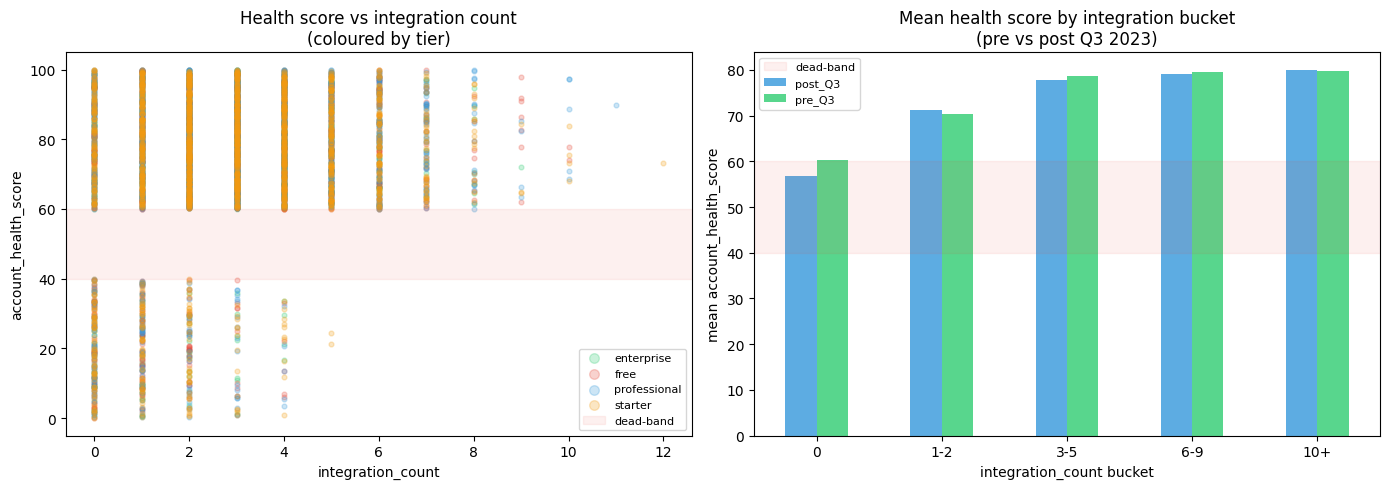

Pearson r(health_score, integration_count):  overall=0.253  pre=0.252  post=0.254


In [17]:
# Testing correlation with integration count

import numpy as np

score_int = ale_df[['account_health_score', 'integration_count', 'subscription_tier']].dropna()
score_int = score_int.assign(
    cohort=ale_df.loc[score_int.index, 'created_timestamp'].ge(Q3_2023_END).map({True: 'post_Q3', False: 'pre_Q3'})
)

tier_colors = {'free': '#e74c3c', 'starter': '#f39c12', 'professional': '#3498db', 'enterprise': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter coloured by tier
for tier, grp in score_int.groupby('subscription_tier'):
    axes[0].scatter(grp['integration_count'], grp['account_health_score'],
                    alpha=0.25, s=12, color=tier_colors.get(tier, '#95a5a6'), label=tier)
axes[0].axhspan(40, 60, color='#e74c3c', alpha=0.08, label='dead-band')
axes[0].set_xlabel('integration_count')
axes[0].set_ylabel('account_health_score')
axes[0].set_title('Health score vs integration count\n(coloured by tier)')
axes[0].legend(fontsize=8, markerscale=2)

# Right: mean health score per integration bucket × cohort
score_int['int_bucket'] = pd.cut(score_int['integration_count'], bins=[0,1,3,6,10,999],
                                  labels=['0', '1-2', '3-5', '6-9', '10+'], right=False)
bucket_means = (score_int.groupby(['int_bucket', 'cohort'], observed=True)['account_health_score']
                .mean().unstack('cohort'))

bucket_means.plot(kind='bar', ax=axes[1], color=['#3498db', '#2ecc71'], alpha=0.8, edgecolor='none')
axes[1].axhspan(40, 60, color='#e74c3c', alpha=0.08, label='dead-band')
axes[1].set_xlabel('integration_count bucket')
axes[1].set_ylabel('mean account_health_score')
axes[1].set_title('Mean health score by integration bucket\n(pre vs post Q3 2023)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Pearson correlation overall and per cohort
r_overall = score_int[['account_health_score', 'integration_count']].corr().iloc[0, 1]
r_pre  = score_int.loc[score_int['cohort'] == 'pre_Q3',  ['account_health_score', 'integration_count']].corr().iloc[0, 1]
r_post = score_int.loc[score_int['cohort'] == 'post_Q3', ['account_health_score', 'integration_count']].corr().iloc[0, 1]

print(f"Pearson r(health_score, integration_count):  overall={r_overall:.3f}  pre={r_pre:.3f}  post={r_post:.3f}")

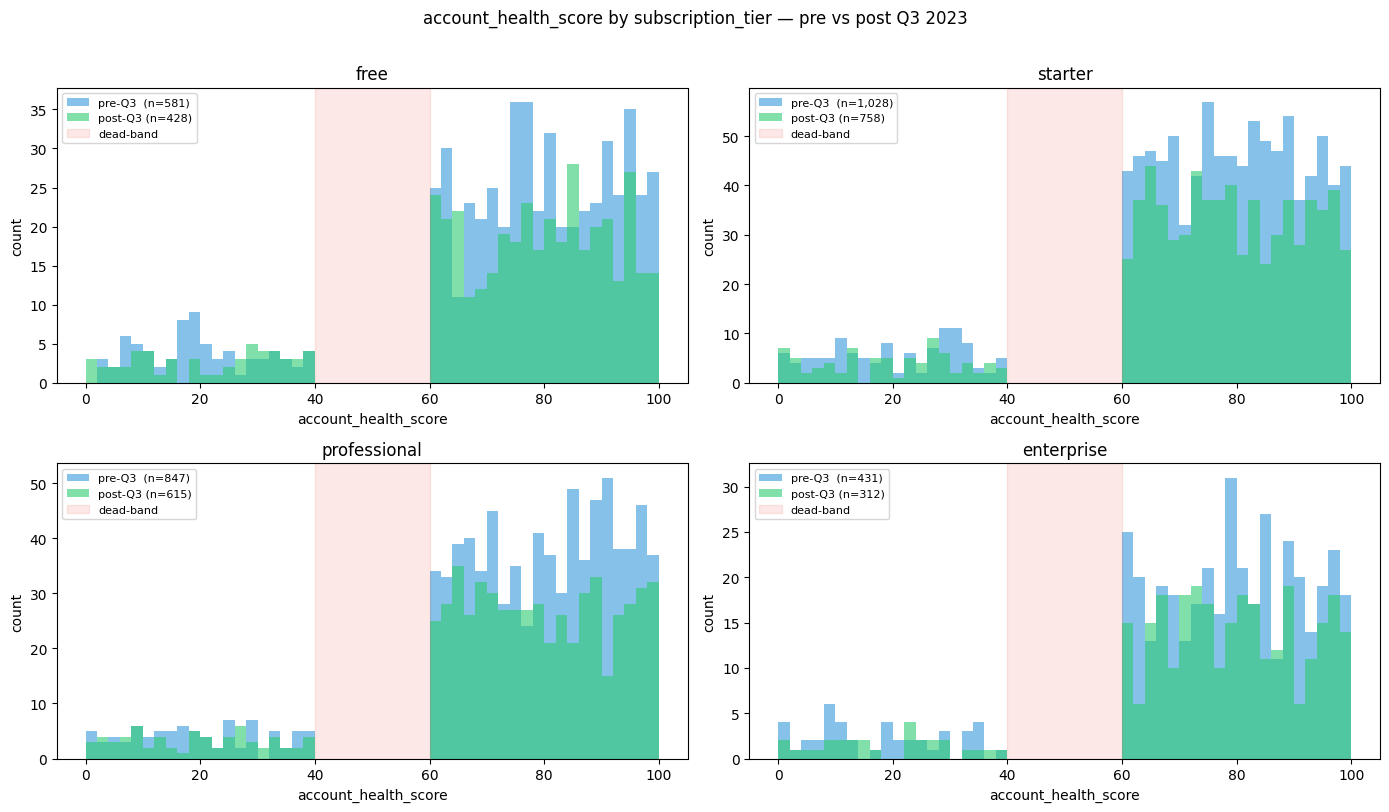

n   mean    std  pct_in_deadband
subscription_tier cohort                                      
enterprise        post_Q3   312  74.49  20.84              0.0
                  pre_Q3    431  73.80  22.11              0.0
free              post_Q3   428  72.59  22.51              0.0
                  pre_Q3    581  72.80  23.19              0.0
professional      post_Q3   615  73.23  22.20              0.0
                  pre_Q3    847  74.64  21.70              0.0
starter           post_Q3   758  73.40  21.78              0.0
                  pre_Q3   1028  73.38  21.97              0.0

In [18]:
# Testing distribution at each subscription tier since there was a 25% correlation

tiers = ['free', 'starter', 'professional', 'enterprise']
tier_order = {t: i for i, t in enumerate(tiers)}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for ax, tier in zip(axes, tiers):
    pre_tier  = ale_df.loc[pre_mask  & (ale_df['subscription_tier'] == tier), 'account_health_score'].dropna()
    post_tier = ale_df.loc[post_mask & (ale_df['subscription_tier'] == tier), 'account_health_score'].dropna()

    ax.hist(pre_tier,  bins=bins, color='#3498db', alpha=0.6, edgecolor='none', label=f'pre-Q3  (n={len(pre_tier):,})')
    ax.hist(post_tier, bins=bins, color='#2ecc71', alpha=0.6, edgecolor='none', label=f'post-Q3 (n={len(post_tier):,})')
    ax.axvspan(40, 60, color='#e74c3c', alpha=0.12, label='dead-band')

    ax.set_title(f'{tier}')
    ax.set_xlabel('account_health_score')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)

plt.suptitle('account_health_score by subscription_tier — pre vs post Q3 2023', y=1.01)
plt.tight_layout()
plt.show()

summary = (
    ale_df.assign(cohort=ale_df['created_timestamp'].ge(Q3_2023_END).map({True: 'post_Q3', False: 'pre_Q3'}))
    .groupby(['subscription_tier', 'cohort'])['account_health_score']
    .agg(n='count', mean='mean', std='std', pct_in_deadband=lambda s: ((s > 40) & (s < 60)).mean() * 100)
    .round(2)
)
display(summary)

In [79]:
# KS test to measure whether pre/post Q3 2023 health score distributions are statistically different
from scipy.stats import ks_2samp

ks_stat, ks_p = ks_2samp(pre_scores, post_scores)

print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value:      {ks_p:.4f}")
print()
if ks_p < 0.05:
    print("Result: SIGNIFICANT")
else:
    print("Result: NOT SIGNIFICANT")

KS statistic: 0.0305
p-value:      0.2021

Result: NOT SIGNIFICANT


In [ ]:
# Test band correlation with account_status

### Investigating the mismatch between uem.user_id and sih.user_id

There is a "legacy sync issue" between these fields. However examining the data confirms UEM uses `USR` + 10 hex chars and SIH uses `USR` + 4 digits so the gap could be more structural than partial mismatches. 


Investigation steps:

1. **Match rate** — fraction of UEM `user_id`s that appear in SIH and vice versa.
2. **Regex format** — confirm the format split is consistent across both tables.
3. **Per-account user-count parity** — for each shared `account_id`, do UEM and SIH agree on how many users that account has?
4. **Per-account ticket-count** - how many `ticker_id` exists per unique `account_id`

If match rate is ~0 and counts disagree, account-level aggregation is the only viable join path.

In [20]:
# Testing direct match rate between uem.user_id and sih.user_id

uem_uids = set(uem_df['user_id'].dropna().unique())
sih_uids = set(sih_df['user_id'].dropna().unique())
overlap  = uem_uids & sih_uids

print(f"Unique user_ids in UEM: {len(uem_uids):,}")
print(f"Unique user_ids in SIH: {len(sih_uids):,}")
print(f"Overlap (intersection): {len(overlap):,}")
print(f"  UEM ids found in SIH: {len(overlap)/len(uem_uids)*100:.2f}%")
print(f"  SIH ids found in UEM: {len(overlap)/len(sih_uids)*100:.2f}%")
print(f"\nSample UEM ids: {list(uem_uids)[:3]}")
print(f"Sample SIH ids: {list(sih_uids)[:3]}")

Unique user_ids in UEM: 13,618
Unique user_ids in SIH: 8,246
Overlap (intersection): 0
  UEM ids found in SIH: 0.00%
  SIH ids found in UEM: 0.00%

Sample UEM ids: ['USRB75E4C2CCB', 'USRF615A2FD1B', 'USR2F4B96D883']
Sample SIH ids: ['USR1094', 'USR3249', 'USR5563']


In [21]:
# Testing regex format matching (do the two columns share an ID scheme?)

import re

UEM_PATTERN = re.compile(r'^USR[0-9A-F]{10}$')   # USR + 10 hex chars
SIH_PATTERN = re.compile(r'^USR[0-9]{4}$')       # USR + 4 digits

def classify(series, label):
    s = series.dropna().astype(str)
    n = len(s)
    matches_uem = s.str.match(UEM_PATTERN).sum()
    matches_sih = s.str.match(SIH_PATTERN).sum()
    other       = n - matches_uem - matches_sih
    print(f"{label}: n={n:,}")
    print(f"  match UEM-style (USR + 10 hex):  {matches_uem:,}  ({matches_uem/n*100:.2f}%)")
    print(f"  match SIH-style (USR + 4 digit): {matches_sih:,}  ({matches_sih/n*100:.2f}%)")
    print(f"  neither:                          {other:,}  ({other/n*100:.2f}%)")
    print()

classify(uem_df['user_id'], 'UEM.user_id')
classify(sih_df['user_id'], 'SIH.user_id')

UEM.user_id: n=13,618
  match UEM-style (USR + 10 hex):  13,618  (100.00%)
  match SIH-style (USR + 4 digit): 0  (0.00%)
  neither:                          0  (0.00%)

SIH.user_id: n=22,385
  match UEM-style (USR + 10 hex):  0  (0.00%)
  match SIH-style (USR + 4 digit): 22,385  (100.00%)
  neither:                          0  (0.00%)



Accounts present in both UEM and SIH: 4,904
  equal user counts:        597  (12.2%)
  SIH has more users:       3,370  (68.7%)
  UEM has more users:       937  (19.1%)

Delta (sih - uem) summary:
count    4904.000000
mean        1.838295
std         3.037490
min        -9.000000
25%         0.000000
50%         2.000000
75%         4.000000
max        13.000000


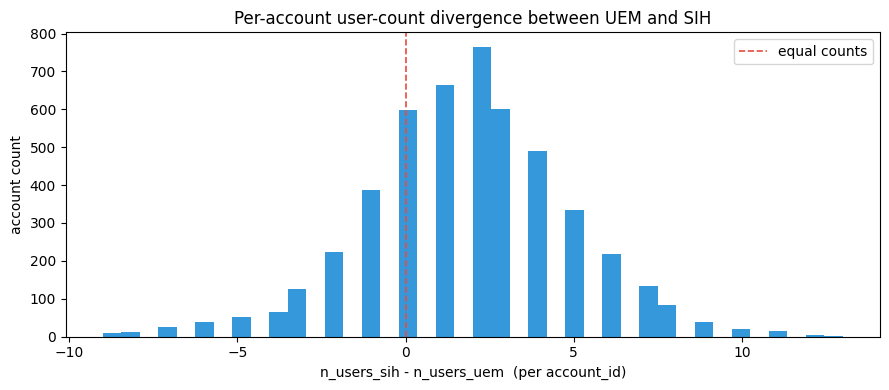

,n_users_uem,n_users_sih,delta
account_id,,,
ACC000000,10,4,-6
ACC000001,2,6,4
ACC000002,5,5,0
ACC000003,2,1,-1
ACC000004,1,2,1
ACC000005,2,3,1
ACC000006,2,2,0
ACC000007,3,7,4
ACC000008,1,4,3


In [22]:
# Testing per-account user-count parity
# For each account_id present in both tables, compare distinct user_id counts.

uem_per_acct = uem_df.groupby('account_id')['user_id'].nunique().rename('n_users_uem')
sih_per_acct = sih_df.groupby('account_id')['user_id'].nunique().rename('n_users_sih')

both = pd.concat([uem_per_acct, sih_per_acct], axis=1, join='inner')
both['delta'] = both['n_users_sih'] - both['n_users_uem']

n_shared = len(both)
n_equal  = (both['delta'] == 0).sum()
n_sih_more = (both['delta'] > 0).sum()
n_uem_more = (both['delta'] < 0).sum()

print(f"Accounts present in both UEM and SIH: {n_shared:,}")
print(f"  equal user counts:        {n_equal:,}  ({n_equal/n_shared*100:.1f}%)")
print(f"  SIH has more users:       {n_sih_more:,}  ({n_sih_more/n_shared*100:.1f}%)")
print(f"  UEM has more users:       {n_uem_more:,}  ({n_uem_more/n_shared*100:.1f}%)")
print(f"\nDelta (sih - uem) summary:")
print(both['delta'].describe().to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(both['delta'], bins=40, color='#3498db', edgecolor='none')
ax.axvline(0, color='#e74c3c', linestyle='--', linewidth=1.2, label='equal counts')
ax.set_xlabel('n_users_sih - n_users_uem  (per account_id)')
ax.set_ylabel('account count')
ax.set_title('Per-account user-count divergence between UEM and SIH')
ax.legend()
plt.tight_layout()
plt.show()

display(both.head(10))

Accounts in ALE: 5,000
  with >=1 ticket: 4,904
  with 0 tickets:  96  (1.9%) -- potential NaN issue

Overall ticket-count summary:
count    5000.000000
mean        4.477000
std         2.451504
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000

By account_status (mean / median / n):


,count,mean,median,max
account_status,,,,
active,4454,4.365290,4.0,15
churned,546,5.388278,5.0,14


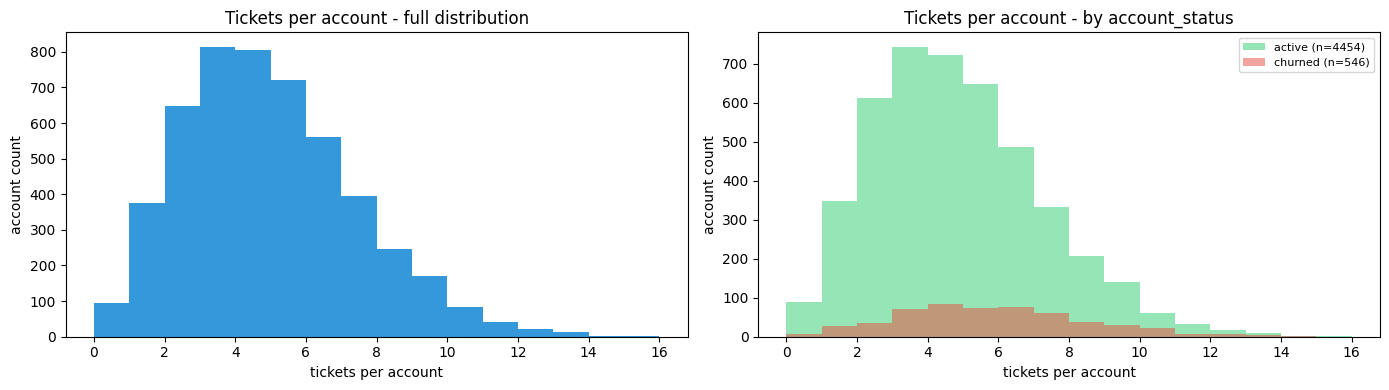

In [23]:
# Testing tickets per account to measure concentration is support volume and the effect of churn

tix_per_acct = sih_df.groupby('account_id').size().rename('n_tickets')
all_accts = ale_df[['account_id', 'account_status']].set_index('account_id')
tix_full = all_accts.join(tix_per_acct).fillna({'n_tickets': 0})
tix_full['n_tickets'] = tix_full['n_tickets'].astype(int)

n_zero = (tix_full['n_tickets'] == 0).sum()
print(f"Accounts in ALE: {len(tix_full):,}")
print(f"  with >=1 ticket: {(tix_full['n_tickets'] > 0).sum():,}")
print(f"  with 0 tickets:  {n_zero:,}  ({n_zero/len(tix_full)*100:.1f}%) -- potential NaN issue")
print(f"\nOverall ticket-count summary:")
print(tix_full['n_tickets'].describe().to_string())

print(f"\nBy account_status (mean / median / n):")
by_status = tix_full.groupby('account_status')['n_tickets'].agg(['count', 'mean', 'median', 'max'])
display(by_status)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(tix_full['n_tickets'], bins=range(0, tix_full['n_tickets'].max() + 2),
             color='#3498db', edgecolor='none')
axes[0].set_xlabel('tickets per account')
axes[0].set_ylabel('account count')
axes[0].set_title('Tickets per account - full distribution')

status_colors = {'active': '#2ecc71', 'churned': '#e74c3c', 'suspended': '#f39c12', 'grace_period': '#9b59b6'}
for status, grp in tix_full.groupby('account_status'):
    axes[1].hist(grp['n_tickets'], bins=range(0, tix_full['n_tickets'].max() + 2),
                 alpha=0.5, label=f'{status} (n={len(grp)})',
                 color=status_colors.get(status, '#95a5a6'), edgecolor='none')
axes[1].set_xlabel('tickets per account')
axes[1].set_ylabel('account count')
axes[1].set_title('Tickets per account - by account_status')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Naive account-level aggregation to build first pass flat table

Aggregation strategies per column informed by business heuristics

**ALE**
Already at the account level

**UEM**
*One account is linked to many users*
- user_id --> num_users
- user_role(member, admin, viewer, billing) --> one hot encoding, sum
- user_status(active, deactivated) --> num_users
- login_count_30d --> sum, average
- login_count_90d --> sum, average
- feature_usage_score --> average, min, max
- sessions_count_30d --> sum, average
- avg_session_duration_minutes --> weighted average with session_count_30d
- reports_generated_30d --> sum, average
- dashboards_created --> sum, average
- dashboards_shared --> sum, average
- exports_count_30d --> sum, average
- api_key_active --> sum, average
- mobile_app_user --> num_mobile_users (all True)
- browser_type --> one_hot_encoding and sum, add spread column
- operating_system --> one_hot_encoding and sum, add spread column
- timezone_offset --> turn into team_geographic_distribution (measures how spread out the teams are based on their timezone)
- language_preference --> one_hot_encoding and sum, add spread column
- notification_preference --> enumerate, sum
- profile_completeness_pct  --> average
- onboarding_completed --> num_onboarding_completed (could correlate highly with num_users)
- certification_earned --> num_certification_earned
- beta_features_enabled --> num_beta_features_enabled
- days_since_last_login --> min (days_since_latest_login), max (days_since_earliest_login)
- days_since_user_creation --> min (days_since_latest_user_creation), max (days_since_earliest_user_creation)

**SIH**
*One account is linked to many tickets*
*The same user can create many tickets within an account*
*Note that not all accounts have tickets, these need to resolve to zeros, not NaN*  
- ticket_id --> num_tickets
- user_id --> num_ticket_creators
- ticket_priority --> enumerate, max, min, average
- ticket_category --> one_hot_encoding, sum, average (leakage risk for 'cancellation_request' maybe could just be a really good signal, consider dropping 100% correlation with cancellation_requested)
- ticket_sentiment --> enumerate, max, min, average
- resolution_time_hours --> max, average, sum
- satisfaction_rating --> num_survey_responses, survey_response_rate, num_low_responses (<2.5), num_high_responses (>2.5)
- escalated --> sum, average
- reopened_count --> sum, max
- cancellation_requested --> sum, average
- cancellation_reason --> num_cancellation_reasons
- retention_offer_made --> sum (could correlate with num_tickets)
- account_pause_requested --> sum (could correlate with num_tickets)
- downgrade_requested --> sum (could correlate with num_tickets)
- competitor_mentioned --> num_competitor_mentions
- agent_id --> num_distinct_agents
- channel --> one_hot_encoding then sum, average
- interaction_count --> sum, average
- iternal_category --> one_hot_encoding, sum (deprecated but could still be used as a signal?)
- sla_breach --> num_sla_breach
- kb_articles_referenced --> sum, average
- days_since_ticket_creation --> min (days_since_latest_ticket_creation), max (days_since_earliest_ticket_creation)
- days_since_resolution --> min (days_since_latest_resolution), max (days_since_earliest_resolution)
- [new] n_tickets_30d (derived, from days_since_ticket_creation)
- [new] n_tickets_90d (derived,from days_since_ticket_creation)

LEAKY_SIH_FIELDS = [`cancellation_requested`, `retention_offer_made`, `downgrade_requested`, `ticket_category` == 'cancellation_reason'ALE_OBVIOUS_DROPS, `account_pause_requested`]

In [24]:
# Aggregating UEM fields to one row per account_id

pd.set_option('display.max_column', None)

g = uem_df.groupby('account_id')

# user counts (overall + by status; 'invited' absent in data)
counts = pd.DataFrame({
    'num_users':             g.size(),
    'num_active_users':      g['user_status'].apply(lambda s: (s == 'active').sum()),
    'num_deactivated_users': g['user_status'].apply(lambda s: (s == 'deactivated').sum()),
})

# user_role one-hot sums (no 'billing' rows in data)
roles = pd.get_dummies(uem_df['user_role']).groupby(uem_df['account_id']).sum()
roles.columns = [f'num_{c}s' for c in roles.columns]

# Activity counters --> per-account sum and average
sums_avgs = {
    'login_count_30d':       ('total_logins_30d',         'avg_logins_30d'),
    'login_count_90d':       ('total_logins_90d',         'avg_logins_90d'),
    'sessions_count_30d':    ('total_sessions_30d',       'avg_sessions_30d'),
    'reports_generated_30d': ('total_reports_30d',        'avg_reports_30d'),
    'dashboards_created':    ('total_dashboards_created', 'avg_dashboards_created'),
    'dashboards_shared':     ('total_dashboards_shared',  'avg_dashboards_shared'),
    'exports_count_30d':     ('total_exports_30d',        'avg_exports_30d'),
}
activity = pd.DataFrame({
    out: (g[src].sum() if out.startswith('total_') else g[src].mean())
    for src, (s_name, a_name) in sums_avgs.items()
    for out in (s_name, a_name)
})

# feature_usage_score --> avg/min/max
fus = g['feature_usage_score'].agg(
    avg_feature_usage_score='mean',
    min_feature_usage_score='min',
    max_feature_usage_score='max',
)

# avg_session_duration_minutes --> weighted by sessions_count_30d (sessions are the natural denominator)
def _weighted_session_duration(grp):
    w, v = grp['sessions_count_30d'], grp['avg_session_duration_minutes']
    tot = w.sum()
    return (v * w).sum() / tot if tot > 0 else np.nan
session_dur = g.apply(_weighted_session_duration).rename('avg_session_duration_minutes')

# Boolean adoption flags --> sum across users in account
bool_sums = pd.DataFrame({
    'num_api_key_active':        g['api_key_active'].sum(),
    'num_mobile_users':          g['mobile_app_user'].sum(),
    'num_onboarding_completed':  g['onboarding_completed'].sum(),
    'num_certification_earned':  g['certification_earned'].sum(),
    'num_beta_features_enabled': g['beta_features_enabled'].sum(),
})

# Categorical spread (nunique is sufficient — class balance across values is even)
spread = pd.DataFrame({
    'n_distinct_browsers':  g['browser_type'].nunique(),
    'n_distinct_os':        g['operating_system'].nunique(),
    'n_distinct_languages': g['language_preference'].nunique(),
})

# Categorical one-hot sums per account (browser / os / language)
browser_oh = pd.get_dummies(uem_df['browser_type'], prefix='num').groupby(uem_df['account_id']).sum()
os_oh      = pd.get_dummies(uem_df['operating_system'], prefix='num').groupby(uem_df['account_id']).sum()
lang_oh    = pd.get_dummies(uem_df['language_preference'], prefix='num_lang').groupby(uem_df['account_id']).sum()

# notification_preference --> ordinal encode then sum / average
notif_ord = uem_df['notification_preference'].map({'none': 0, 'important': 1, 'all': 2})
notif = pd.DataFrame({
    'total_notification_pref': notif_ord.groupby(uem_df['account_id']).sum(),
    'avg_notification_pref':   notif_ord.groupby(uem_df['account_id']).mean(),
})

# timezone_offset --> spread (distinct count + std)
tz = pd.DataFrame({
    'tz_nunique': g['timezone_offset'].nunique(),
    'tz_std':     g['timezone_offset'].std(),
})

# profile_completeness_pct --> account average
profile = g['profile_completeness_pct'].mean().rename('avg_profile_completeness_pct')

# Recency: min = most recent event, max = oldest event in account
recency = pd.DataFrame({
    'days_since_latest_login':           g['days_since_last_login'].min(),
    'days_since_earliest_login':         g['days_since_last_login'].max(),
    'days_since_latest_user_creation':   g['days_since_user_creation'].min(),
    'days_since_earliest_user_creation': g['days_since_user_creation'].max(),
})

uem_agg = pd.concat(
    [counts, roles, activity, fus, session_dur, bool_sums, spread,
     browser_oh, os_oh, lang_oh, notif, tz, profile, recency],
    axis=1,
)
print(f"uem_agg: {uem_agg.shape}")
uem_agg.head(5)

uem_agg: (5000, 54)


,num_users,num_active_users,num_deactivated_users,num_admins,num_members,num_viewers,total_logins_30d,avg_logins_30d,total_logins_90d,avg_logins_90d,total_sessions_30d,avg_sessions_30d,total_reports_30d,avg_reports_30d,total_dashboards_created,avg_dashboards_created,total_dashboards_shared,avg_dashboards_shared,total_exports_30d,avg_exports_30d,avg_feature_usage_score,min_feature_usage_score,max_feature_usage_score,avg_session_duration_minutes,num_api_key_active,num_mobile_users,num_onboarding_completed,num_certification_earned,num_beta_features_enabled,n_distinct_browsers,n_distinct_os,n_distinct_languages,num_chrome,num_edge,num_firefox,num_safari,num_android,num_ios,num_linux,num_macos,num_windows,num_lang_de,num_lang_en,num_lang_es,num_lang_fr,total_notification_pref,avg_notification_pref,tz_nunique,tz_std,avg_profile_completeness_pct,days_since_latest_login,days_since_earliest_login,days_since_latest_user_creation,days_since_earliest_user_creation
account_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACC000000,10,10,0,1,8,1,169,16.9,481,48.1,140,14.0,94,9.4,43,4.3,13,1.3,64,6.4,85.180028,48.898875,105.948078,38.447794,1,2,10,1,0,4,5,4,2,3,2,3,1,1,2,1,5,3,2,3,2,11,1.1,7,7.846443,79.717720,2,22,797,861
ACC000001,2,2,0,1,1,0,39,19.5,105,52.5,46,23.0,19,9.5,6,3.0,1,0.5,8,4.0,63.675367,44.588427,82.762308,38.580497,0,0,2,1,0,1,1,2,2,0,0,0,0,2,0,0,0,1,0,1,0,1,0.5,2,5.656854,66.742778,2,19,1020,1046
ACC000002,5,5,0,1,3,1,31,6.2,96,19.2,29,5.8,50,10.0,15,3.0,3,0.6,36,7.2,82.221391,66.738654,103.656500,40.902222,0,2,5,1,0,3,4,2,1,0,1,3,2,0,1,1,1,0,0,3,2,6,1.2,4,8.018728,56.160053,3,143,446,506
ACC000003,2,2,0,1,1,0,24,12.0,68,34.0,22,11.0,14,7.0,6,3.0,0,0.0,7,3.5,52.949230,52.792859,53.105601,28.109832,1,1,2,0,1,2,2,1,0,1,1,0,0,1,0,1,0,0,2,0,0,3,1.5,2,9.899495,73.227182,14,16,537,592
ACC000004,1,1,0,1,0,0,0,0.0,0,0.0,0,0.0,11,11.0,6,6.0,2,2.0,12,12.0,111.039446,111.039446,111.039446,NaN,0,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,2,2.0,1,NaN,99.503659,134,134,614,614


In [25]:
# Aggregating SIH fields to one row per account_id

pd.set_option('display.max_column', None)

# LEAKY columns: drop these before training a deployable model. Keep computed for baseline comparison.
LEAKY_SIH_FIELDS = [
    'total_cancellation_requested', 'rate_cancellation_requested',
    'num_cancellation', 'rate_cancellation',
    'num_cancellation_reasons',
    'total_retention_offer_made',
    'total_account_pause_requested',
    'total_downgrade_requested',
]

PRIORITY_MAP  = {'low': 0, 'medium': 1, 'high': 2, 'critical': 3}
SENTIMENT_MAP = {'frustrated': 0, 'negative': 1, 'neutral': 2, 'positive': 3}

g = sih_df.groupby('account_id')

# Counts
counts = pd.DataFrame({
    'num_tickets':          g.size(),
    'num_ticket_creators':  g['user_id'].nunique(),
    'num_distinct_agents':  g['agent_id'].nunique(),
})

# ticket_priority / ticket_sentiment --> ordinal encode then min/max/avg
prio_ord = sih_df['ticket_priority'].map(PRIORITY_MAP)
sent_ord = sih_df['ticket_sentiment'].map(SENTIMENT_MAP)
ordinal = pd.DataFrame({
    'max_priority':  prio_ord.groupby(sih_df['account_id']).max(),
    'min_priority':  prio_ord.groupby(sih_df['account_id']).min(),
    'avg_priority':  prio_ord.groupby(sih_df['account_id']).mean(),
    'max_sentiment': sent_ord.groupby(sih_df['account_id']).max(),
    'min_sentiment': sent_ord.groupby(sih_df['account_id']).min(),
    'avg_sentiment': sent_ord.groupby(sih_df['account_id']).mean(),
})

# ticket_category one-hot --> sum (count) and mean (rate)
cat_oh = pd.get_dummies(sih_df['ticket_category']).groupby(sih_df['account_id'])
cat_sums  = cat_oh.sum().add_prefix('num_')
cat_rates = cat_oh.mean().add_prefix('rate_')

# resolution_time_hours --> max / avg / sum
resolution = g['resolution_time_hours'].agg(
    max_resolution_hours='max',
    avg_resolution_hours='mean',
    total_resolution_hours='sum',
)

# satisfaction_rating --> response-rate primary signal (~69% null), plus low/high counts (cutoff 2.5 per plan)
csat = sih_df['satisfaction_rating']
csat_df = pd.DataFrame({
    'num_csat_responses':  csat.notna().groupby(sih_df['account_id']).sum(),
    'csat_response_rate':  csat.notna().groupby(sih_df['account_id']).mean(),
    'num_low_csat':        csat.lt(2.5).groupby(sih_df['account_id']).sum(),
    'num_high_csat':       csat.gt(2.5).groupby(sih_df['account_id']).sum(),
})

# Boolean ticket flags --> sums (and rate where useful)
bools = pd.DataFrame({
    'total_escalated':                g['escalated'].sum(),
    'rate_escalated':                 g['escalated'].mean(),
    'total_sla_breach':               g['sla_breach'].sum(),
    'total_cancellation_requested':   g['cancellation_requested'].sum(),     # LEAKY
    'rate_cancellation_requested':    g['cancellation_requested'].mean(),    # LEAKY
    'total_retention_offer_made':     g['retention_offer_made'].sum(),       # LEAKY
    'total_account_pause_requested':  g['account_pause_requested'].sum(),    # LEAKY
    'total_downgrade_requested':      g['downgrade_requested'].sum(),        # LEAKY
})

# reopened_count --> sum + max
reopened = g['reopened_count'].agg(total_reopened='sum', max_reopened='max')

# Free-text presence --> count of non-null entries per account
text_counts = pd.DataFrame({
    'num_cancellation_reasons':  sih_df['cancellation_reason'].notna().groupby(sih_df['account_id']).sum(),  # LEAKY
    'num_competitor_mentions':   sih_df['competitor_mentioned'].notna().groupby(sih_df['account_id']).sum(),
})

# channel one-hot --> count + rate
ch_oh = pd.get_dummies(sih_df['channel']).groupby(sih_df['account_id'])
ch_sums  = ch_oh.sum().add_prefix('num_')
ch_rates = ch_oh.mean().add_prefix('rate_')

# interaction_count --> total + avg
inter = g['interaction_count'].agg(total_interactions='sum', avg_interactions='mean')

# internal_category (deprecated; 0% null today, but train/serve skew risk if phase-out begins)
ic_null_rate = sih_df['internal_category'].isna().mean()
if ic_null_rate < 0.5:
    ic_oh = pd.get_dummies(sih_df['internal_category'], prefix='num_internal').groupby(sih_df['account_id']).sum()
else:
    print(f"internal_category null rate {ic_null_rate:.1%} — skipping (phase-out underway)")
    ic_oh = pd.DataFrame(index=g.size().index)

# kb_articles_referenced --> total + avg
kb = g['kb_articles_referenced'].agg(total_kb_articles='sum', avg_kb_articles='mean')

# Recency: min = most recent, max = oldest
recency = pd.DataFrame({
    'days_since_latest_ticket_creation':   g['days_since_ticket_creation'].min(),
    'days_since_earliest_ticket_creation': g['days_since_ticket_creation'].max(),
    'days_since_latest_resolution':        g['days_since_resolution'].min(),
    'days_since_earliest_resolution':      g['days_since_resolution'].max(),
})

# Windowed ticket counts derived from days_since_ticket_creation
days = sih_df['days_since_ticket_creation']
windows = pd.DataFrame({
    'n_tickets_30d': days.le(30).groupby(sih_df['account_id']).sum(),
    'n_tickets_90d': days.le(90).groupby(sih_df['account_id']).sum(),
})

sih_agg = pd.concat(
    [counts, ordinal, cat_sums, cat_rates, resolution, csat_df, bools, reopened,
     text_counts, ch_sums, ch_rates, inter, ic_oh, kb, recency, windows],
    axis=1,
)
print(f"sih_agg: {sih_agg.shape}")
print(f"LEAKY_SIH_FIELDS ({len(LEAKY_SIH_FIELDS)}): {LEAKY_SIH_FIELDS}")
sih_agg.head(5)

sih_agg: (4904, 59)
LEAKY_SIH_FIELDS (8): ['total_cancellation_requested', 'rate_cancellation_requested', 'num_cancellation', 'rate_cancellation', 'num_cancellation_reasons', 'total_retention_offer_made', 'total_account_pause_requested', 'total_downgrade_requested']


,num_tickets,num_ticket_creators,num_distinct_agents,max_priority,min_priority,avg_priority,max_sentiment,min_sentiment,avg_sentiment,num_billing,num_bug,num_cancellation,num_feature_request,num_technical,rate_billing,rate_bug,rate_cancellation,rate_feature_request,rate_technical,max_resolution_hours,avg_resolution_hours,total_resolution_hours,num_csat_responses,csat_response_rate,num_low_csat,num_high_csat,total_escalated,rate_escalated,total_sla_breach,total_cancellation_requested,rate_cancellation_requested,total_retention_offer_made,total_account_pause_requested,total_downgrade_requested,total_reopened,max_reopened,num_cancellation_reasons,num_competitor_mentions,num_chat,num_email,num_phone,num_self_service,rate_chat,rate_email,rate_phone,rate_self_service,total_interactions,avg_interactions,num_internal_cat_a,num_internal_cat_b,num_internal_cat_c,total_kb_articles,avg_kb_articles,days_since_latest_ticket_creation,days_since_earliest_ticket_creation,days_since_latest_resolution,days_since_earliest_resolution,n_tickets_30d,n_tickets_90d
account_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACC000000,4,4,4,2,2,2.0,2,1,1.500000,1,2,0,0,1,0.250000,0.500000,0.0,0.0,0.250000,41.839001,32.458673,129.834693,1,0.250000,1,0,2,0.500000,4,0,0.0,0,0,0,4,2,0,0,1,1,0,2,0.25,0.250000,0.000000,0.500000,16,4.000000,1,2,1,11,2.75,342,854,340,852,0,0
ACC000001,7,6,6,2,0,1.0,2,1,1.428571,2,3,0,0,2,0.285714,0.428571,0.0,0.0,0.285714,64.521854,37.492658,262.448607,3,0.428571,3,0,2,0.285714,7,0,0.0,0,0,0,7,4,0,0,0,2,4,1,0.00,0.285714,0.571429,0.142857,36,5.142857,2,2,3,7,1.00,243,1004,241,1002,0,0
ACC000002,5,5,5,3,2,2.2,2,1,1.400000,1,1,0,2,1,0.200000,0.200000,0.0,0.4,0.200000,37.822025,32.986979,164.934896,0,0.000000,0,0,2,0.400000,5,0,0.0,0,0,0,7,4,0,0,0,2,1,2,0.00,0.400000,0.200000,0.400000,21,4.200000,2,2,1,5,1.00,188,527,186,525,0,0
ACC000003,1,1,1,1,1,1.0,3,3,3.000000,0,0,0,1,0,0.000000,0.000000,0.0,1.0,0.000000,20.129521,20.129521,20.129521,1,1.000000,0,1,0,0.000000,0,0,0.0,0,0,0,0,0,0,0,0,1,0,0,0.00,1.000000,0.000000,0.000000,4,4.000000,0,0,1,0,0.00,419,419,418,418,0,0
ACC000004,2,2,2,1,1,1.0,2,2,2.000000,0,1,0,0,1,0.000000,0.500000,0.0,0.0,0.500000,25.121786,22.622851,45.245702,0,0.000000,0,0,0,0.000000,1,0,0.0,0,0,0,2,2,0,0,2,0,0,0,1.00,0.000000,0.000000,0.000000,11,5.500000,1,1,0,0,0.00,226,626,224,625,0,0


In [80]:
# Build pp_df by left-merging the aggregated UEM and SIH frames into ALE on account_id.

pp_df = ale_df.merge(uem_agg, how='left', on='account_id').merge(sih_agg, how='left', on='account_id')

# Accounts with 0 tickets get NaN from the SIH merge. Those should resolve to 0
sih_recency_cols = [
    'days_since_latest_ticket_creation', 'days_since_earliest_ticket_creation',
    'days_since_latest_resolution', 'days_since_earliest_resolution',
]
sih_zero_fill = [c for c in sih_agg.columns if c not in sih_recency_cols]
pp_df[sih_zero_fill] = pp_df[sih_zero_fill].fillna(0)

# UEM aggregates that are mathematically undefined for some accounts (collapse to 0)
# Instead, we build spreads for these rows to capture variability between users
pp_df[['avg_session_duration_minutes', 'tz_std']] = pp_df[['avg_session_duration_minutes', 'tz_std']].fillna(0)

# Sanity checks
assert pp_df['account_id'].is_unique, "row inflation from merge"
print(f"pp_df shape: {pp_df.shape}")
print(f"NaNs in SIH count/rate/sum cols (expect 0): {pp_df[sih_zero_fill].isna().sum().sum()}")
print(f"NaN rate in ticket recency cols (expect ~2%):")
print((pp_df[sih_recency_cols].isna().mean() * 100).round(1).to_string())
pp_df.head(5)

pp_df shape: (5000, 143)
NaNs in SIH count/rate/sum cols (expect 0): 0
NaN rate in ticket recency cols (expect ~2%):
days_since_latest_ticket_creation      1.9
days_since_earliest_ticket_creation    1.9
days_since_latest_resolution           1.9
days_since_earliest_resolution         1.9


,account_id,account_uuid,org_id,created_timestamp,last_activity_timestamp,account_status,status_change_date,subscription_tier,mrr,billing_cycle,payment_method,auto_renew_enabled,seats_purchased,seats_active,contract_end_date,account_health_score,risk_flag,region,account_manager_id,integration_count,api_calls_enabled,sso_enabled,white_label_enabled,data_residency_region,provisioning_method,internal_notes_count,days_since_creation,days_since_last_activity,days_since_contract_end,days_since_status_change,num_users,num_active_users,num_deactivated_users,num_admins,num_members,num_viewers,total_logins_30d,avg_logins_30d,total_logins_90d,avg_logins_90d,total_sessions_30d,avg_sessions_30d,total_reports_30d,avg_reports_30d,total_dashboards_created,avg_dashboards_created,total_dashboards_shared,avg_dashboards_shared,total_exports_30d,avg_exports_30d,avg_feature_usage_score,min_feature_usage_score,max_feature_usage_score,avg_session_duration_minutes,num_api_key_active,num_mobile_users,num_onboarding_completed,num_certification_earned,num_beta_features_enabled,n_distinct_browsers,n_distinct_os,n_distinct_languages,num_chrome,num_edge,num_firefox,num_safari,num_android,num_ios,num_linux,num_macos,num_windows,num_lang_de,num_lang_en,num_lang_es,num_lang_fr,total_notification_pref,avg_notification_pref,tz_nunique,tz_std,avg_profile_completeness_pct,days_since_latest_login,days_since_earliest_login,days_since_latest_user_creation,days_since_earliest_user_creation,num_tickets,num_ticket_creators,num_distinct_agents,max_priority,min_priority,avg_priority,max_sentiment,min_sentiment,avg_sentiment,num_billing,num_bug,num_cancellation,num_feature_request,num_technical,rate_billing,rate_bug,rate_cancellation,rate_feature_request,rate_technical,max_resolution_hours,avg_resolution_hours,total_resolution_hours,num_csat_responses,csat_response_rate,num_low_csat,num_high_csat,total_escalated,rate_escalated,total_sla_breach,total_cancellation_requested,rate_cancellation_requested,total_retention_offer_made,total_account_pause_requested,total_downgrade_requested,total_reopened,max_reopened,num_cancellation_reasons,num_competitor_mentions,num_chat,num_email,num_phone,num_self_service,rate_chat,rate_email,rate_phone,rate_self_service,total_interactions,avg_interactions,num_internal_cat_a,num_internal_cat_b,num_internal_cat_c,total_kb_articles,avg_kb_articles,days_since_latest_ticket_creation,days_since_earliest_ticket_creation,days_since_latest_resolution,days_since_earliest_resolution,n_tickets_30d,n_tickets_90d
0,ACC000000,NaN,ORG00697,2022-08-17,2024-12-21,active,2023-12-17,professional,182.372000,annual,credit_card,True,35,8,2024-08-16,94.849799,False,EU,AM34,4,True,False,True,EU,sales_led,0,869,12,139,382,10,10,0,1,8,1,169,16.9,481,48.1,140,14.0,94,9.4,43,4.3,13,1.3,64,6.4,85.180028,48.898875,105.948078,38.447794,1,2,10,1,0,4,5,4,2,3,2,3,1,1,2,1,5,3,2,3,2,11,1.1,7,7.846443,79.717720,2,22,797,861,4.0,4.0,4.0,2.0,2.0,2.0,2.0,1.0,1.500000,1.0,2.0,0.0,0.0,1.0,0.250000,0.500000,0.0,0.0,0.250000,41.839001,32.458673,129.834693,1.0,0.250000,1.0,0.0,2.0,0.500000,4.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,0.0,0.0,1.0,1.0,0.0,2.0,0.25,0.250000,0.000000,0.500000,16.0,4.000000,1.0,2.0,1.0,11.0,2.75,342.0,854.0,340.0,852.0,0.0,0.0
1,ACC000001,NaN,ORG00246,2022-02-21,2024-12-22,active,2023-01-02,professional,200.941898,monthly,invoice,True,33,9,2024-02-21,86.324272,False,LATAM,AM34,3,False,False,False,LATAM,self_serve,0,1046,11,316,731,2,2,0,1,1,0,39,19.5,105,52.5,46,23.0,19,9.5,6,3.0,1,0.5,8,4.0,63.675367,44.588427,82.762308,38.580497,0,0,2,1,0,1,1,2,2,0,0,0,0,2,0,0,0,1,0,1,0,1,0.5,2,5.656854,66.742778,2,19,1020,1046,7.0,6.0,6.0,2.0,0.0,1.0,2.0,1.0,1.428571,2.0,3.0,0.0,0.0,2.0,0.285714,0.428571,0.0,0.0,0.285714,64.521854,37.492658,262.448607,3.0,0.428571,3.0,0.0,2.0,0.285714,7.0,0.0,0.0,0.0,0.0,0.0,7.0,4.0,0.0,0.0,0.0,2.0,4.0,1.0,0.00,0.285714,0.571429,0.142857,36.0,5.142857,2.0,2.0,3.0,7.0,1.00,243.0,1004.0,241.0,1002.0,0.0,0.0
2,ACC000002,NaN,ORG01163,2023-07-18,2024-12-10,

In [27]:
# Final ALE preprocessing — drops, encodings, target binarization

# 1. ID + leakage + datetime drops
ALE_DROPS = [
    'account_id', 'org_id', 'account_manager_id',          # identifiers
    *ALE_OBVIOUS_DROPS,                                     # account_uuid, data_residency_region (see cell 17)
    'days_since_status_change',                             # leakage: 21% forward-looking
    'created_timestamp', 'last_activity_timestamp',         # datetime sources (durations already derived)
    'status_change_date', 'contract_end_date',
]
pp_df.drop(columns=ALE_DROPS, inplace=True)

# 2. Target: churned vs not
pp_df['account_status'] = (pp_df['account_status'] == 'churned').astype(int)

# 3. subscription_tier --> ordinal
TIER_MAP = {'free': 1, 'starter': 2, 'professional': 3, 'enterprise': 4}
pp_df['subscription_tier'] = pp_df['subscription_tier'].map(TIER_MAP)

# 4. account_health_score --> band (50 = middle of dead-band, see cell 22)
pp_df['health_score_band'] = (pp_df['account_health_score'] >= 50).astype(int)
pp_df.drop(columns=['account_health_score'], inplace=True)

# 5. Nominal categoricals --> one-hot
for col in ['region', 'billing_cycle', 'payment_method', 'provisioning_method']:
    oh = pd.get_dummies(pp_df[col], prefix=col).astype(int)
    pp_df.drop(columns=[col], inplace=True)
    pp_df = pd.concat([pp_df, oh], axis=1)

# 6. Booleans --> int
BOOL_COLS = ['auto_renew_enabled', 'risk_flag',
             'api_calls_enabled', 'sso_enabled', 'white_label_enabled']
pp_df[BOOL_COLS] = pp_df[BOOL_COLS].astype(int)

# Sanity: no object/datetime dtypes remain
non_numeric = pp_df.select_dtypes(exclude='number').columns.tolist()
assert not non_numeric, f"non-numeric cols remain: {non_numeric}"
print(f"pp_df shape: {pp_df.shape}")
print(f"churn rate: {pp_df['account_status'].mean():.1%}")
print(f"dtypes: {pp_df.dtypes.value_counts().to_dict()}")

pp_df shape: (5000, 142)
churn rate: 10.9%
dtypes: {dtype('float64'): 74, dtype('int64'): 68}


In [28]:
# pp_df is built; ale_df / uem_df / sih_df now mirror data/raw and are read-only.
#
# One-off sweetviz snapshot — uncomment to regenerate data/profiles/pp_report.html.
# pp_df.to_csv('../data/preprocessed/pp_report.csv', index=False)
# import sweetviz as sv
# pp_report = sv.analyze(pp_df)
# pp_report.show_html("../data/profiles/pp_report.html", open_browser=False)


/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[Step 3/3] Generating associations graph     |          | [  0%]   00:00 -> (? left)    /Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/sweetviz/graph_associations.py:219: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_dataframe[feature] = pd.Series(dtype=float)
/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/sweetviz/graph_associations.py:219: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

Report ../data/profiles/pp_report.html was generated.


## Post-preprocessing drops

Drops informed by the preprocessed frame: leakage surfaced by univariate distribution checks, sweetviz association tables, and the L1/RF model-based selectors. Source frames remain unchanged so the merge can be re-run without re-deriving features.


In [29]:
# Confirmed leakage — distribution checks + model-based selectors flagged these as extremely correlating fields

LEAKAGE_DROPS = [
    'health_score_band',          # encodes account_health_score, algorithm proxies churn risk
    'risk_flag',                  
    'days_since_last_activity',   # post-churn drift inflates churned-tail (median 63 vs active 18)
    'num_competitor_mentions',    # 100% zero on active vs 78% nonzero on churned — exit-conversation flag
]

pp_df.drop(columns=LEAKAGE_DROPS + LEAKY_SIH_FIELDS, inplace=True)
print(f"pp_df shape after leakage drops: {pp_df.shape}")


pp_df shape after leakage drops: (5000, 130)


## Feature selection

Experiments:
1. Variance threshold
2. Pairwise correlation prune
3. Univariate filters (drop filters all columns together by MI)
4. RF and L1 logistic regression feature importance


In [30]:
# Experiment 1 — Variance threshold
# Drops near-constants: binary cols where dominant class >99%, continuous where std/|mean| < 1e-3.

TARGET = 'account_status'
features = pp_df.drop(columns=[TARGET])

# "binary" if non-null values are a subset of {0, 1}
binary_cols, continuous_cols = [], []
for c in features.columns:
    vals = features[c].dropna().unique()
    (binary_cols if set(vals).issubset({0, 1}) else continuous_cols).append(c)

binary_share = features[binary_cols].apply(lambda s: max(s.mean(), 1 - s.mean()))
binary_drops = binary_share[binary_share > 0.99].index.tolist()

# coefficient of variation, robust to scale
mu = features[continuous_cols].mean().abs()
sd = features[continuous_cols].std()
cv = sd / mu.replace(0, np.nan)
cont_drops = cv[(cv < 1e-3) | (sd < 1e-9)].index.tolist()

variance_drops = binary_drops + cont_drops
print(f"binary cols: {len(binary_cols)}, continuous cols: {len(continuous_cols)}")
print(f"binary drops ({len(binary_drops)}): {binary_drops}")
print(f"continuous drops ({len(cont_drops)}): {cont_drops}")

pp_df.drop(columns=variance_drops, inplace=True)
print(f"\npp_df shape after variance prune: {pp_df.shape}")


binary cols: 18, continuous cols: 111
binary drops (1): ['num_admins']
continuous drops (0): []

pp_df shape after variance prune: (5000, 129)


In [31]:
# Experiment 2 — Pairwise correlation prune
# For each pair |corr| > 0.9, drop the one with weaker target correlation. Spearman to catch monotonic redundancy.

THRESH = 0.9

X = pp_df.drop(columns=[TARGET])
y = pp_df[TARGET]

# Median-impute just for the diagnostic; NaNs would propagate in corr().
X_imp = X.fillna(X.median(numeric_only=True))

corr = X_imp.corr(method='spearman').abs()
target_corr = X_imp.corrwith(y, method='spearman').abs()

upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
to_drop = set()
pairs_logged = []
for col in upper.columns:
    for row, val in upper[col].dropna().items():
        if val <= THRESH:
            continue
        if row in to_drop or col in to_drop:
            continue
        loser = row if target_corr[row] < target_corr[col] else col
        to_drop.add(loser)
        pairs_logged.append((row, col, round(val, 3),
                             round(target_corr[row], 3), round(target_corr[col], 3), loser))

print(f"pairs above |r|>{THRESH}: {len(pairs_logged)}")
print(f"unique drops: {len(to_drop)}")
if pairs_logged:
    pairs_df = pd.DataFrame(pairs_logged,
        columns=['feat_a', 'feat_b', '|r|', '|r_a,y|', '|r_b,y|', 'dropped'])
    print(pairs_df.to_string(index=False))

pp_df.drop(columns=list(to_drop), inplace=True)
print(f"\npp_df shape after correlation prune: {pp_df.shape}")


pairs above |r|>0.9: 21
unique drops: 21
                             feat_a                            feat_b   |r|  |r_a,y|  |r_b,y|                           dropped
                  subscription_tier                               mrr 0.962    0.029    0.028                               mrr
                    seats_purchased                      seats_active 0.932    0.027    0.087                   seats_purchased
                          num_users                  num_active_users 0.984    0.006    0.008                         num_users
                   total_logins_30d                  total_logins_90d 0.996    0.151    0.152                  total_logins_30d
                     avg_logins_30d                    avg_logins_90d 0.990    0.213    0.210                    avg_logins_90d
                   total_logins_90d                total_sessions_30d 0.967    0.152    0.148                total_sessions_30d
                     avg_logins_30d                  avg_sessio

In [32]:
# Experiment 3 — Univariate filters (ANOVA F, chi², mutual information)
# Diagnostic only: produces a ranked table; does not auto-drop. Top features may be leakage (risk_flag, health_score_band) — re-check CLAUDE.md before promoting.

from sklearn.feature_selection import f_classif, chi2, mutual_info_classif

X = pp_df.drop(columns=[TARGET])
y = pp_df[TARGET]
X_imp = X.fillna(X.median(numeric_only=True))

# Re-classify after the prior drops
binary_cols = [c for c in X_imp.columns if set(X_imp[c].dropna().unique()).issubset({0, 1})]
continuous_cols = [c for c in X_imp.columns if c not in binary_cols]

# ANOVA F on continuous (chi² needs non-negative; some continuous cols can go negative)
f_stat, f_p = f_classif(X_imp[continuous_cols], y)
anova = pd.Series(f_stat, index=continuous_cols, name='anova_F')

chi_stat, chi_p = chi2(X_imp[binary_cols], y)
chi = pd.Series(chi_stat, index=binary_cols, name='chi2')

mi = pd.Series(
    mutual_info_classif(X_imp, y, discrete_features=[c in binary_cols for c in X_imp.columns],
                        random_state=0),
    index=X_imp.columns, name='mutual_info',
)

ranks = pd.DataFrame(index=X_imp.columns)
ranks['anova_F_rank'] = anova.rank(ascending=False)
ranks['chi2_rank']    = chi.rank(ascending=False)
ranks['mi_rank']      = mi.rank(ascending=False)
ranks['mi']           = mi
ranks['avg_rank']     = ranks[['anova_F_rank', 'chi2_rank', 'mi_rank']].mean(axis=1)
ranks = ranks.sort_values('avg_rank')

print(f"features evaluated: {ranks.shape[0]}")
print("\nTop 25 by average rank (lower = stronger):")
print(ranks.head(25).to_string())
print("\nBottom 25 (candidates to drop):")
print(ranks.tail(25).to_string())


features evaluated: 107

Top 25 by average rank (lower = stronger):
                              anova_F_rank  chi2_rank  mi_rank        mi  avg_rank
avg_feature_usage_score                1.0        NaN      1.0  0.071613       1.0
integration_count                      2.0        NaN      2.0  0.068696       2.0
avg_reports_30d                        3.0        NaN      6.0  0.029837       4.5
avg_session_duration_minutes           4.0        NaN      5.0  0.031272       4.5
avg_dashboards_shared                  5.0        NaN      8.0  0.027981       6.5
avg_dashboards_created                 7.0        NaN      7.0  0.028008       7.0
total_dashboards_shared               13.0        NaN      4.0  0.032857       8.5
avg_exports_30d                        6.0        NaN     12.0  0.025280       9.0
avg_resolution_hours                  10.0        NaN      9.0  0.027840       9.5
avg_logins_30d                         8.0        NaN     11.0  0.025408       9.5
total_reopened     

In [33]:
# Apply the univariate drop rule
# Hard drop = MI < 1e-3 AND failing applicable secondary test (chi² for binary, ANOVA F for continuous) at its bottom quartile.

MI_FLOOR = 1e-3

anova_q25 = anova.quantile(0.25)
chi_q25   = chi.quantile(0.25)

binary_now = [c for c in mi.index if c in chi.index]
cont_now   = [c for c in mi.index if c in anova.index]

hard_drops = []
for c in mi.index:
    if mi[c] >= MI_FLOOR:
        continue
    if c in binary_now and chi[c] < chi_q25:
        hard_drops.append(c)
    elif c in cont_now and anova[c] < anova_q25:
        hard_drops.append(c)

# Leakage watchlist — surface in top-20, do not auto-drop
LEAKAGE_PATTERNS = ['risk_flag', 'health_score_band', 'cancellation', 'status_change',
                    'retention_offer', 'pause_requested', 'downgrade_requested']
top20 = ranks.head(20).index.tolist()
leakage_in_top = [c for c in top20 if any(p in c for p in LEAKAGE_PATTERNS)]

print(f"hard drops ({len(hard_drops)}):")
for c in hard_drops:
    print(f"  {c:40s}  mi={mi[c]:.4f}")
print(f"\nleakage candidates in top-20 (review, do not auto-drop):")
for c in leakage_in_top:
    print(f"  {c}")

pp_df.drop(columns=hard_drops, inplace=True)
print(f"\npp_df shape after univariate prune: {pp_df.shape}")
print(f"events-per-parameter: {int(pp_df[TARGET].sum()) / (pp_df.shape[1] - 1):.1f}")


hard drops (15):
  num_beta_features_enabled                 mi=0.0000
  n_distinct_os                             mi=0.0000
  num_firefox                               mi=0.0000
  num_safari                                mi=0.0000
  num_macos                                 mi=0.0000
  avg_profile_completeness_pct              mi=0.0000
  csat_response_rate                        mi=0.0000
  rate_chat                                 mi=0.0000
  rate_email                                mi=0.0003
  avg_interactions                          mi=0.0000
  avg_kb_articles                           mi=0.0000
  region_EU                                 mi=0.0000
  region_LATAM                              mi=0.0000
  region_NA                                 mi=0.0000
  billing_cycle_annual                      mi=0.0000

leakage candidates in top-20 (review, do not auto-drop):

pp_df shape after univariate prune: (5000, 93)
events-per-parameter: 5.9


## Leakage audit — `integration_count`

integration_count shows η ≈ 0.31 association with account_status in sweetviz — gray-zone territory. The mechanism to rule out: do churning accounts rip out integrations during offboarding? If so, the feature is partly measuring the outcome rather than predicting it.

Distribution check below: if active and churned distributions overlap meaningfully, the feature is a switching-cost signal (keep). If churned mostly clusters at zero with active mostly nonzero, it's an offboarding artifact (drop or cap).


In [ ]:
# Distribution check — same playbook used on num_competitor_mentions and days_since_last_activity

import numpy as np

col = 'integration_count'
print(f"{col}:")
print(pp_df.groupby(TARGET)[col].describe().round(2))
print(f"\n  zero rate by status:")
print(pp_df.groupby(TARGET)[col].apply(lambda s: (s == 0).mean()).round(3))
print(f"\n  histogram by status (counts in 0-2-4-6-8-10-15-20-30-50+ bins):")
bins = [0, 1, 3, 5, 7, 10, 15, 20, 30, 50, np.inf]
for status, label in [(0, 'active '), (1, 'churned')]:
    h, _ = np.histogram(pp_df.loc[pp_df[TARGET] == status, col], bins=bins)
    print(f"  {label}: {dict(zip(['<1','1-2','3-4','5-6','7-9','10-14','15-19','20-29','30-49','50+'], h))}")


## Leakage audit — days_since_contract_end

days_since_contract_end survived to the locked feature set with a small positive coefficient (+0.06, perm imp 0.005). Two reasons to audit it now:

| Concern | Mechanism |
|---|---|
| Operational leakage shape | The data dictionary notes that contract_end_date semantics differ by cycle: "for annual contracts only; monthly contracts show next renewal date." For a monthly account, the value rolls forward each renewal; once the account churns, renewals stop, so the field is frozen by the churn event itself. Same leakage shape as days_since_status_change (already dropped at 21% post-snapshot). |
| Semantic mixing | billing_cycle was one-hot encoded earlier but didn't survive feature selection, so the model sees one numeric column with two different meanings. |

Same playbook as the integration_count, num_competitor_mentions, and days_since_last_activity audits: distribution by status, then split by billing_cycle to test the semantic-mixing hypothesis.


In [70]:
# Distribution check on ale_df (raw, pre-merge — has billing_cycle and account_status as strings)

col = 'days_since_contract_end'
print(f"{col} — overall split by status:")
print(ale_df.groupby('account_status')[col].describe().round(1))

print(f"\n  sign rate by status (positive = past expiry, negative = future):")
print(ale_df.groupby('account_status')[col].apply(
    lambda s: pd.Series({
        'frac_negative':    (s < 0).mean(),
        'frac_zero_or_pos': (s >= 0).mean(),
        'null_rate':        s.isna().mean(),
    })
).round(3))

print(f"\n  status x billing_cycle — median days_since_contract_end (semantic-mixing test):")
print(ale_df.groupby(['billing_cycle', 'account_status'])[col].median().round(1).unstack())

print(f"\n  status x billing_cycle — fraction past expiry (>= 0):")
print(ale_df.groupby(['billing_cycle', 'account_status'])[col]
        .apply(lambda s: (s >= 0).mean()).round(3).unstack())

print(f"\n  status x billing_cycle — count:")
print(ale_df.groupby(['billing_cycle', 'account_status']).size().unstack(fill_value=0))


days_since_contract_end — overall split by status:
                 count  mean    std    min    25%  50%    75%    max
account_status                                                      
active          4454.0  -3.0  361.1 -728.0 -278.0 -5.0  266.0  732.0
churned          546.0  15.9  301.6 -719.0  -58.8 -9.5  142.5  727.0

  sign rate by status (positive = past expiry, negative = future):
account_status                  
active          frac_negative       0.505
                frac_zero_or_pos    0.495
                null_rate           0.000
churned         frac_negative       0.540
                frac_zero_or_pos    0.460
                null_rate           0.000
Name: days_since_contract_end, dtype: float64

  status x billing_cycle — median days_since_contract_end (semantic-mixing test):
account_status  active  churned
billing_cycle                  
annual           -15.0     -8.0
monthly            1.0     -9.0
quarterly        -23.0    -38.0

  status x billing_cycle — fra

In [34]:
# Model-based selection: L1 logistic + RF permutation importance.
# Two complementary views: L1 is sparse/linear/signed; RF perm importance catches nonlinearity. Features in BOTH are robust.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

X = pp_df.drop(columns=[TARGET]).fillna(pp_df.median(numeric_only=True))
y = pp_df[TARGET]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0,
)

# L1 needs scale-comparable inputs to be fair across features
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

l1 = LogisticRegressionCV(
    Cs=10, penalty='l1', solver='saga', scoring='roc_auc',
    cv=5, max_iter=5000, class_weight='balanced', n_jobs=-1, random_state=0,
)
l1.fit(X_tr_s, y_tr)
l1_coef = pd.Series(l1.coef_.ravel(), index=X.columns, name='l1_coef')
l1_kept = l1_coef[l1_coef.abs() > 1e-6].sort_values(key=abs, ascending=False)
l1_auc = roc_auc_score(y_te, l1.predict_proba(X_te_s)[:, 1])
print(f"L1 logistic — chosen C: {l1.C_[0]:.4f}, AUC(test): {l1_auc:.3f}")
print(f"L1 surviving features: {len(l1_kept)} / {X.shape[1]}")

rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=20,
    class_weight='balanced', n_jobs=-1, random_state=0,
)
rf.fit(X_tr, y_tr)
rf_auc = roc_auc_score(y_te, rf.predict_proba(X_te)[:, 1])
print(f"\nRF AUC(test): {rf_auc:.3f}")

perm = permutation_importance(rf, X_te, y_te, n_repeats=10, random_state=0, n_jobs=-1, scoring='roc_auc')
perm_imp = pd.Series(perm.importances_mean, index=X.columns, name='perm_importance')

combined = pd.DataFrame({
    'l1_coef':         l1_coef,
    'l1_abs':          l1_coef.abs(),
    'perm_importance': perm_imp,
})
combined['in_l1']   = combined['l1_abs'] > 1e-6
combined['in_perm'] = combined['perm_importance'] > 0
combined['in_both'] = combined['in_l1'] & combined['in_perm']
combined = combined.sort_values(['in_both', 'perm_importance', 'l1_abs'], ascending=False)

n_both = int(combined['in_both'].sum())
n_l1_only = int((combined['in_l1'] & ~combined['in_perm']).sum())
n_perm_only = int((~combined['in_l1'] & combined['in_perm']).sum())
n_neither = int((~combined['in_l1'] & ~combined['in_perm']).sum())
print(f"\nfeatures kept by both selectors: {n_both}")
print(f"L1 only: {n_l1_only}")
print(f"perm only: {n_perm_only}")
print(f"neither: {n_neither}")
print(f"\nrecommended core feature set ('both' selectors agree, n={n_both})")
print(f"projected EPP at this size: {int(y.sum()) / max(n_both, 1):.1f}")

print("\nTop 30 by perm importance (with L1 coefficient):")
print(combined.head(30).to_string())


/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified 

L1 logistic — chosen C: 0.3594, AUC(test): 0.963
L1 surviving features: 77 / 92

RF AUC(test): 0.912

features kept by both selectors: 33
L1 only: 44
perm only: 5
neither: 10

--- recommended core feature set ('both' selectors agree, n=33) ---
projected EPP at this size: 16.5

Top 30 by perm importance (with L1 coefficient):
                                      l1_coef    l1_abs  perm_importance  in_l1  in_perm  in_both
integration_count                   -1.739096  1.739096         0.050393   True     True     True
subscription_tier                   -0.366770  0.366770         0.021415   True     True     True
avg_feature_usage_score             -0.827404  0.827404         0.010874   True     True     True
avg_logins_30d                      -0.325430  0.325430         0.007317   True     True     True
days_since_contract_end              0.058800  0.058800         0.005211   True     True     True
seats_active                        -0.046583  0.046583         0.003944   True     T

### Lock in feature set

Final feature set is the intersection of two rules:

1. Both selectors agree — survived L1 logistic and had positive permutation importance on RF.
2. Permutation importance ≥ 1e-3 — below this, features contribute < 0.1% AUC and including them makes per-account explanations harder.

Result lands at roughly 15 features → EPP ≈ 36, inside the safe zone for stable logistic regression and simple enough for the chat interface to explain feature contributions per account.


In [39]:
# Lock in the final feature set on pp_df. feature_df = pp_df.copy() inherits this trimmed schema in the next section.

PERM_FLOOR = 1e-3

# Drop colinear with rate counterparts
NUM_TICKET_DROPS = ['num_billing', 'num_bug', 'num_technical', 'num_feature_request']

feature_df = pp_df.copy()

keepers = combined[combined['in_both'] & (combined['perm_importance'] >= PERM_FLOOR)].index.tolist()
keepers = [c for c in keepers if c not in NUM_TICKET_DROPS]

LOCKED_FEATURES = sorted(keepers)
unselected = [c for c in feature_df.columns if c not in LOCKED_FEATURES + [TARGET]]

print(f"locked features ({len(LOCKED_FEATURES)}):")
for c in LOCKED_FEATURES:
    print(f"  {c:40s}  perm={combined.loc[c, 'perm_importance']:.4f}  l1_coef={combined.loc[c, 'l1_coef']:+.3f}")

feature_df.drop(columns=unselected, inplace=True)

print(f"\npp_df shape (locked): {feature_df.shape}")
print(f"events-per-parameter: {int(feature_df[TARGET].sum()) / len(LOCKED_FEATURES):.1f}")


locked features (13):
  avg_dashboards_shared                     perm=0.0033  l1_coef=+0.011
  avg_feature_usage_score                   perm=0.0109  l1_coef=-0.827
  avg_logins_30d                            perm=0.0073  l1_coef=-0.325
  days_since_contract_end                   perm=0.0052  l1_coef=+0.059
  days_since_earliest_login                 perm=0.0010  l1_coef=+0.028
  integration_count                         perm=0.0504  l1_coef=-1.739
  rate_billing                              perm=0.0018  l1_coef=-0.501
  rate_bug                                  perm=0.0021  l1_coef=-0.441
  rate_feature_request                      perm=0.0029  l1_coef=-0.620
  rate_technical                            perm=0.0024  l1_coef=-0.139
  seats_active                              perm=0.0039  l1_coef=-0.047
  subscription_tier                         perm=0.0214  l1_coef=-0.367
  total_logins_90d                          perm=0.0023  l1_coef=-0.292

pp_df shape (locked): (5000, 14)
events-p

## Model Selection

Choosing the right ML model to train an accurate and generalizable classifier for account status.

Candidates:
- Logistic Regression
- Random Forest
- XGBoost


In [47]:
# Train / test split

from sklearn.model_selection import train_test_split

target = ['account_status']
X = feature_df.drop(columns=target)
y = feature_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      # preserve positive rate
    random_state=1,  # reproducibility
)

print("training set shapes:", X_train.shape, y_train.shape)
print("test set shapes:", X_test.shape, y_test.shape)


training set shapes:  (4000, 13) (4000, 1)
test set shapes:  (1000, 13) (1000, 1)


In [53]:
# Logistic regression baseline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.99      0.97       891
           1       0.85      0.59      0.70       109

    accuracy                           0.94      1000
   macro avg       0.90      0.79      0.83      1000
weighted avg       0.94      0.94      0.94      1000



/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [60]:
# Random Forest baseline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.94      1.00      0.97       891
           1       0.93      0.47      0.62       109

    accuracy                           0.94      1000
   macro avg       0.93      0.73      0.79      1000
weighted avg       0.94      0.94      0.93      1000



In [59]:
# XGBoost baseline

from xgboost import XGBClassifier
from sklearn.metrics import classification_report

model = XGBClassifier(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.99      0.98       891
           1       0.93      0.69      0.79       109

    accuracy                           0.96      1000
   macro avg       0.94      0.84      0.88      1000
weighted avg       0.96      0.96      0.96      1000



### Threshold tuning for precision/recall trade-off

Reconfiguring precision / recall outcomes since classification_report evaluates each model at the default 0.5 probability threshold.


/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:38:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


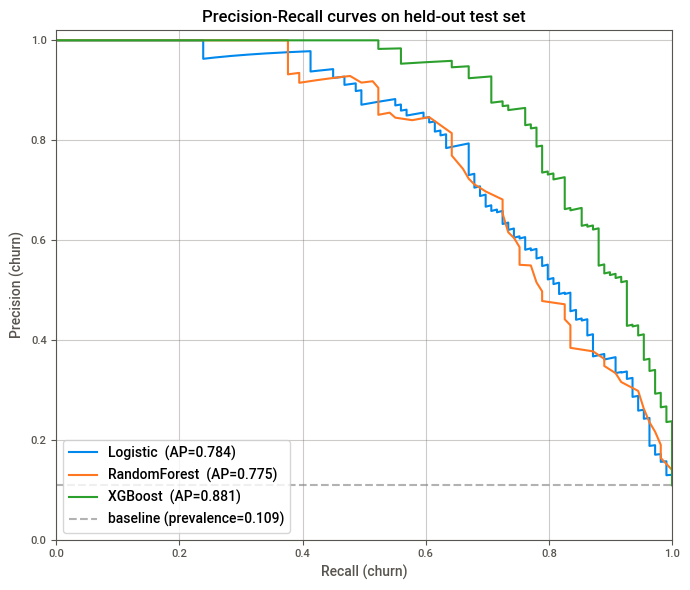

XGBoost — threshold sweep (class 1 = churn):
 threshold  flagged  TP  FP  FN  precision  recall    F1    F2
      0.10      166  96  70  13      0.578   0.881 0.698 0.797
      0.15      133  90  43  19      0.677   0.826 0.744 0.791
      0.20      114  86  28  23      0.754   0.789 0.771 0.782
      0.25      102  84  18  25      0.824   0.771 0.796 0.781
      0.30       97  83  14  26      0.856   0.761 0.806 0.779
      0.35       91  79  12  30      0.868   0.725 0.790 0.750
      0.40       88  77  11  32      0.875   0.706 0.782 0.735
      0.45       84  77   7  32      0.917   0.706 0.798 0.740
      0.50       81  75   6  34      0.926   0.688 0.789 0.725
      0.55       76  72   4  37      0.947   0.661 0.778 0.703
      0.60       74  70   4  39      0.946   0.642 0.765 0.686
      0.65       68  65   3  44      0.956   0.596 0.734 0.645
      0.70       67  64   3  45      0.955   0.587 0.727 0.636
      0.75       62  61   1  48      0.984   0.560 0.713 0.612
      0.80

In [61]:
# Refit the three candidates and pull predicted probabilities for class 1 (churn). Self-contained for reproducibility.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

models = {
    'Logistic':     LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=1),
    'XGBoost':      XGBClassifier(n_estimators=100, learning_rate=0.1,
                                  use_label_encoder=False, eval_metric='logloss', random_state=1),
}

probas = {}
for name, m in models.items():
    m.fit(X_train, y_train.values.ravel())
    probas[name] = m.predict_proba(X_test)[:, 1]

# Precision-recall curves
fig, ax = plt.subplots(figsize=(7, 6))
for name, p in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    ax.plot(rec, prec, label=f'{name}  (AP={ap:.3f})')

# baseline = always-predict-positive precision == prevalence
prevalence = float(np.mean(y_test.values))
ax.axhline(prevalence, ls='--', color='grey', alpha=0.6,
           label=f'baseline (prevalence={prevalence:.3f})')
ax.set_xlabel('Recall (churn)')
ax.set_ylabel('Precision (churn)')
ax.set_title('Precision-Recall curves on held-out test set')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Threshold sweep on the winner (XGBoost). F-beta = (1+b²)·P·R / (b²·P + R)
p = probas['XGBoost']
thresholds = np.arange(0.10, 0.91, 0.05)
rows = []
y_true = y_test.values.ravel()
for t in thresholds:
    y_hat = (p >= t).astype(int)
    tp = int(((y_hat == 1) & (y_true == 1)).sum())
    fp = int(((y_hat == 1) & (y_true == 0)).sum())
    fn = int(((y_hat == 0) & (y_true == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    def fbeta(b):
        denom = (b * b * prec) + rec
        return (1 + b * b) * prec * rec / denom if denom else 0.0
    rows.append({
        'threshold': round(t, 2), 'flagged': int((y_hat == 1).sum()),
        'TP': tp, 'FP': fp, 'FN': fn,
        'precision': round(prec, 3), 'recall': round(rec, 3),
        'F1': round(fbeta(1), 3), 'F2': round(fbeta(2), 3),
    })
sweep = pd.DataFrame(rows)
print('XGBoost — threshold sweep (class 1 = churn):')
print(sweep.to_string(index=False))

best_f1 = sweep.loc[sweep['F1'].idxmax()]
best_f2 = sweep.loc[sweep['F2'].idxmax()]
print(f"\nbest-F1 threshold: {best_f1['threshold']:.2f}  "
      f"(P={best_f1['precision']:.2f}, R={best_f1['recall']:.2f}, F1={best_f1['F1']:.2f})")
print(f"best-F2 threshold: {best_f2['threshold']:.2f}  "
      f"(P={best_f2['precision']:.2f}, R={best_f2['recall']:.2f}, F2={best_f2['F2']:.2f})")


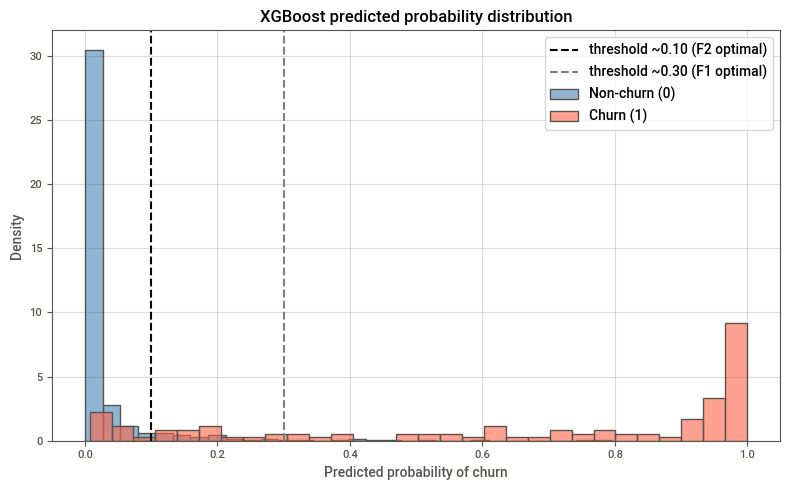

In [68]:
# Distribution of XGBoost predicted probabilities by status

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

p = probas['XGBoost']
y = y_test.values.ravel()

plt.figure(figsize=(8, 5))

sns.histplot(p[y == 0], bins=30, color='steelblue', alpha=0.6, label='Non-churn (0)', stat='density')
sns.histplot(p[y == 1], bins=30, color='tomato',    alpha=0.6, label='Churn (1)',     stat='density')

plt.axvline(0.10, color='black', linestyle='--', label='threshold ~0.10 (F2 optimal)')
plt.axvline(0.30, color='gray',  linestyle='--', label='threshold ~0.30 (F1 optimal)')

plt.title('XGBoost predicted probability distribution')
plt.xlabel('Predicted probability of churn')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


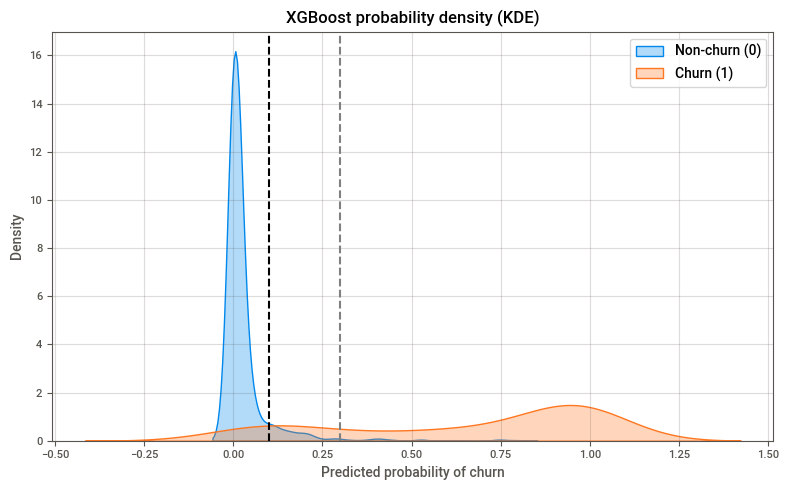

In [69]:
# KDE view of the same probability distribution

plt.figure(figsize=(8, 5))

sns.kdeplot(p[y == 0], label='Non-churn (0)', fill=True, alpha=0.3)
sns.kdeplot(p[y == 1], label='Churn (1)',     fill=True, alpha=0.3)

plt.axvline(0.10, color='black', linestyle='--')
plt.axvline(0.30, color='gray',  linestyle='--')

plt.title('XGBoost probability density (KDE)')
plt.xlabel('Predicted probability of churn')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### Calibration & operationalization

The held-out set in the threshold-tuning cells above shows a strong ranker (AUPRC ≈ 0.88) but says nothing about probability calibration — whether a 0.20 prediction actually corresponds to ~20% observed churn rate. The serving consumer asks per-account questions like "what's the churn probability for ACC000456?", so the predicted value needs to be a defensible probability, not just a relative score.

Three experiments below:

| Experiment | Purpose |
|---|---|
| Reliability curve | Bin held-out predictions, compare mean predicted vs observed frequency. Compare raw XGB to isotonic and Platt-scaled variants. |
| Per-decile metrics | Translate ranking strength into stakeholder-facing numbers: what does the top decile actually catch, and at what precision/lift? |
| Top-K targeting | Instead of a fixed threshold, what threshold flags the top-K accounts? Useful when CS intervention capacity is the binding constraint. |


/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [02:01:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [02:01:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [02:01:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [02:01:51] WARNING: /Users/

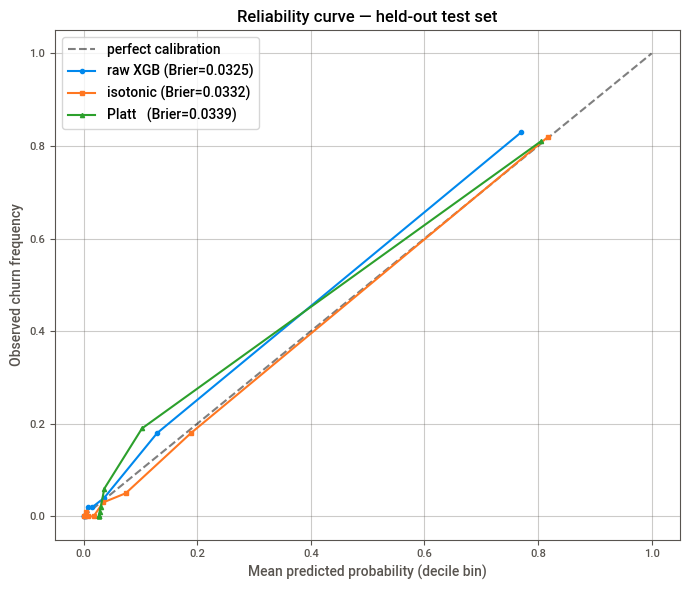

Test base rate:           0.1090
Mean predicted (raw):     0.0969
Mean predicted (isotonic):0.1149
Mean predicted (Platt):   0.1138

Brier scores (lower is better):
  raw XGB : 0.0325
  isotonic: 0.0332
  Platt   : 0.0339


In [71]:
# Reliability curve + post-hoc calibration (isotonic vs Platt).
# CalibratedClassifierCV uses 5-fold internal CV on (X_train, y_train) so calibration is not fit on the rows that get scored.

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

p_raw = probas['XGBoost']
y = y_test.values.ravel()

xgb_base = XGBClassifier(n_estimators=100, learning_rate=0.1,
                         use_label_encoder=False, eval_metric='logloss', random_state=1)
cal_iso = CalibratedClassifierCV(xgb_base, method='isotonic', cv=5).fit(X_train, y_train.values.ravel())
cal_sig = CalibratedClassifierCV(xgb_base, method='sigmoid',  cv=5).fit(X_train, y_train.values.ravel())
p_iso = cal_iso.predict_proba(X_test)[:, 1]
p_sig = cal_sig.predict_proba(X_test)[:, 1]

# Quantile binning so each bin has ~equal sample size
prob_true_raw, prob_pred_raw = calibration_curve(y, p_raw, n_bins=10, strategy='quantile')
prob_true_iso, prob_pred_iso = calibration_curve(y, p_iso, n_bins=10, strategy='quantile')
prob_true_sig, prob_pred_sig = calibration_curve(y, p_sig, n_bins=10, strategy='quantile')

brier_raw = brier_score_loss(y, p_raw)
brier_iso = brier_score_loss(y, p_iso)
brier_sig = brier_score_loss(y, p_sig)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect calibration')
ax.plot(prob_pred_raw, prob_true_raw, 'o-', label=f'raw XGB (Brier={brier_raw:.4f})')
ax.plot(prob_pred_iso, prob_true_iso, 's-', label=f'isotonic (Brier={brier_iso:.4f})')
ax.plot(prob_pred_sig, prob_true_sig, '^-', label=f'Platt   (Brier={brier_sig:.4f})')
ax.set_xlabel('Mean predicted probability (decile bin)')
ax.set_ylabel('Observed churn frequency')
ax.set_title('Reliability curve — held-out test set')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Test base rate:           {y.mean():.4f}")
print(f"Mean predicted (raw):     {p_raw.mean():.4f}")
print(f"Mean predicted (isotonic):{p_iso.mean():.4f}")
print(f"Mean predicted (Platt):   {p_sig.mean():.4f}")
print(f"\nBrier scores (lower is better):")
print(f"  raw XGB : {brier_raw:.4f}")
print(f"  isotonic: {brier_iso:.4f}")
print(f"  Platt   : {brier_sig:.4f}")


In [72]:
# Per-decile metrics on raw XGB probabilities.
# Translates AUPRC into stakeholder-facing numbers: what does each tenth of the scored portfolio actually catch?

p = probas['XGBoost']
y = y_test.values.ravel()
n = len(y)
total_pos = int(y.sum())
prevalence = total_pos / n

# Rank descending, bucket into deciles (1 = top)
order = np.argsort(-p)
ranks = np.empty_like(order)
ranks[order] = np.arange(n)
decile = (ranks * 10 // n) + 1

rows = []
for d in range(1, 11):
    mask = decile == d
    n_d = int(mask.sum())
    pos_d = int(y[mask].sum())
    rows.append({
        'decile':         d,
        'prob_min':       round(float(p[mask].min()), 4) if n_d else 0.0,
        'prob_max':       round(float(p[mask].max()), 4) if n_d else 0.0,
        'n':              n_d,
        'positives':      pos_d,
        'precision':      round(pos_d / n_d, 3) if n_d else 0.0,
        'lift_vs_base':   round((pos_d / n_d) / prevalence, 2) if n_d else 0.0,
    })
df = pd.DataFrame(rows)
df['cum_positives']  = df['positives'].cumsum()
df['cum_n']          = df['n'].cumsum()
df['cum_recall']     = (df['cum_positives'] / total_pos).round(3)
df['cum_precision']  = (df['cum_positives'] / df['cum_n']).round(3)

print(f"Held-out: n={n}, positives={total_pos}, prevalence={prevalence:.3%}")
print('Per-decile breakdown (1 = highest predicted-churn 10%):\n')
print(df[['decile','prob_min','prob_max','n','positives',
         'precision','lift_vs_base','cum_positives','cum_recall','cum_precision']]
      .to_string(index=False))


Held-out: n=1000, positives=109, prevalence=10.900%
Per-decile breakdown (1 = highest predicted-churn 10%):

 decile  prob_min  prob_max   n  positives  precision  lift_vs_base  cum_positives  cum_recall  cum_precision
      1    0.2824    0.9993 100         83       0.83          7.61             83       0.761          0.830
      2    0.0573    0.2789 100         18       0.18          1.65            101       0.927          0.505
      3    0.0224    0.0569 100          4       0.04          0.37            105       0.963          0.350
      4    0.0106    0.0223 100          2       0.02          0.18            107       0.982          0.268
      5    0.0052    0.0106 100          2       0.02          0.18            109       1.000          0.218
      6    0.0030    0.0051 100          0       0.00          0.00            109       1.000          0.182
      7    0.0019    0.0030 100          0       0.00          0.00            109       1.000          0.156
      8    

In [73]:
# Top-K targeting: what threshold flags the top K accounts, and what precision/recall do we get?
# Mirrors how a CS team with finite weekly intervention capacity actually consumes the model.

p = probas['XGBoost']
y = y_test.values.ravel()
n_test = len(y)
total_pos = int(y.sum())
prevalence = total_pos / n_test

# K_full_5000 column scales K to the full 5000-row scoring frame for sizing
ks = [10, 25, 50, 75, 100, 150, 250]
order = np.argsort(-p)

rows = []
for K in ks:
    idx = order[:K]
    tp = int(y[idx].sum())
    threshold_at_k = float(p[order[K-1]])
    rows.append({
        'K':                 K,
        'pct_of_test':       round(K / n_test * 100, 1),
        'K_full_5000':       int(round(K * 5000 / n_test)),
        'threshold_implied': round(threshold_at_k, 4),
        'TP':                tp,
        'FP':                K - tp,
        'precision@K':       round(tp / K, 3),
        'recall@K':          round(tp / total_pos, 3),
        'lift':              round((tp / K) / prevalence, 2),
    })
df_topk = pd.DataFrame(rows)
print(f"Top-K targeting (held-out: n={n_test}, prevalence={prevalence:.3%}):\n")
print(df_topk.to_string(index=False))

# Compare to the locked F2-tuned threshold of 0.10
n_at_010 = int((p >= 0.10).sum())
tp_at_010 = int(((p >= 0.10) & (y == 1)).sum())
print(f"\nFor reference, fixed threshold 0.10 flags {n_at_010} accounts "
      f"({n_at_010 / n_test * 100:.1f}% of test set), TP={tp_at_010}, "
      f"precision={tp_at_010/n_at_010:.3f}, recall={tp_at_010/total_pos:.3f}.")

Top-K targeting (held-out: n=1000, prevalence=10.900%):

  K  pct_of_test  K_full_5000  threshold_implied  TP  FP  precision@K  recall@K  lift
 10          1.0           50             0.9944  10   0        1.000     0.092  9.17
 25          2.5          125             0.9761  25   0        1.000     0.229  9.17
 50          5.0          250             0.9119  50   0        1.000     0.459  9.17
 75          7.5          375             0.5718  71   4        0.947     0.651  8.69
100         10.0          500             0.2824  83  17        0.830     0.761  7.61
150         15.0          750             0.1189  94  56        0.627     0.862  5.75
250         25.0         1250             0.0357 103 147        0.412     0.945  3.78

For reference, fixed threshold 0.10 flags 166 accounts (16.6% of test set), TP=96, precision=0.578, recall=0.881.


### Persist model artifacts

| File | Purpose |
|---|---|
| xgb_churn.json | Fitted XGBoost — saved via XGBoost's native portable JSON format. |
| feature_columns.json | The locked feature list in column order — XGBoost predicts positionally, so this is the train/inference contract. |
| config.json | Threshold, beta, training metadata, held-out metrics. The app reads this to know how to use the model, not just what the model is. |

Refit happens on the full feature_df (not just X_train). The held-out evaluation already validated the recipe; the deployed artifact should use every row available.


In [62]:
# Persist the deployable artifacts.

import json
from pathlib import Path
from datetime import datetime, timezone
from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score, precision_score, recall_score, f1_score, fbeta_score,
)

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

THRESHOLD = 0.10
BETA      = 2

# Refit on the full labeled dataset using the validated config
X_full = feature_df.drop(columns=target)
y_full = feature_df[target].values.ravel()

final_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=1,
)
final_model.fit(X_full, y_full)

# 1. Model weights — native JSON format (version-portable, not pickle)
final_model.save_model(MODELS_DIR / 'xgb_churn.json')

# 2. Column contract — order matters; XGBoost predicts positionally
feature_columns = list(X_full.columns)
with open(MODELS_DIR / 'feature_columns.json', 'w') as f:
    json.dump(feature_columns, f, indent=2)

# 3. Config — threshold + held-out metrics + training metadata
y_test_arr = y_test.values.ravel()
p_test = probas['XGBoost']
y_hat_at_t = (p_test >= THRESHOLD).astype(int)

config = {
    'model': 'xgboost',
    'trained_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'n_training_rows': int(len(X_full)),
    'n_features': len(feature_columns),
    'threshold': THRESHOLD,
    'beta': BETA,
    'holdout_metrics': {
        'note': 'computed on a single 80/20 stratified split (random_state=1); '
                'reported for reference. Final model above is refit on full data.',
        'n_test_rows': int(len(y_test_arr)),
        'n_test_positives': int(y_test_arr.sum()),
        'average_precision': round(float(average_precision_score(y_test_arr, p_test)), 4),
        'at_threshold': {
            'threshold':  THRESHOLD,
            'precision':  round(float(precision_score(y_test_arr, y_hat_at_t)), 4),
            'recall':     round(float(recall_score(y_test_arr, y_hat_at_t)), 4),
            'f1':         round(float(f1_score(y_test_arr, y_hat_at_t)), 4),
            f'f{BETA}':   round(float(fbeta_score(y_test_arr, y_hat_at_t, beta=BETA)), 4),
        },
    },
}
with open(MODELS_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Wrote artifacts to', MODELS_DIR.resolve())
for p in sorted(MODELS_DIR.iterdir()):
    print(f'  {p.name:25s}  {p.stat().st_size:>8,} bytes')
print()
print('Config:')
print(json.dumps(config, indent=2))


Wrote artifacts to /Users/vidyutveedgav/churnguard-analytics/models
  config.json                     548 bytes
  feature_columns.json            302 bytes
  xgb_churn.json              473,678 bytes

Config:
{
  "model": "xgboost",
  "trained_at": "2026-05-04T02:09:50+00:00",
  "n_training_rows": 5000,
  "n_features": 13,
  "threshold": 0.1,
  "beta": 2,
  "holdout_metrics": {
    "note": "computed on a single 80/20 stratified split (random_state=1); reported for reference. Final model above is refit on full data.",
    "n_test_rows": 1000,
    "n_test_positives": 109,
    "average_precision": 0.8805,
    "at_threshold": {
      "threshold": 0.1,
      "precision": 0.5783,
      "recall": 0.8807,
      "f1": 0.6982,
      "f2": 0.7973
    }
  }
}


/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:09:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
